In [13]:
# not so intuitive abbreviations:
# DS = Dataset
# .CP = CellPop in use
# .SD = Standard Deviation
# .EE = Everything else
# .SM = Signaling molecules

# Setup

In [14]:
#essential reticulate functions (must run first)
Sys.setenv(RETICULATE_PYTHON="/home/luca/anaconda3/envs/reticulate/bin/python")
library(reticulate)
reticulate::use_python("/home/luca/anaconda3/envs/reticulate/bin/python")
reticulate::use_condaenv("/home/luca/anaconda3/envs/reticulate")
reticulate::py_module_available(module='anndata') #needs to be TRUE
reticulate::import('anndata') #good to make sure this doesn't error

[1] TRUE

Module(anndata)

## Load libraries

In [15]:
options(scipen=999)
pacman::p_load(dplyr, stringr, data.table, tidyr, plyr, forcats, logr,grid, ggh4x, FSA,
               Rmagic, phateR, parallel,gridExtra,ggplot2, ggpubr, ggrepel, ggbreak, gridExtra, patchwork, grid, ggh4x,
               pheatmap, colorRamps, gridExtra, ggplot2, ggrepel, RColorBrewer,ComplexHeatmap,vioplot,ggforce,grid)

## Working Directories and Options

In [16]:
assets.dir = "/nfs/lab/projects/CellCrosstalk/npod.pancreas/Final/Assets/"
cc.db = "/nfs/lab/projects/islet_multiomics_stress/analysis/CellChat/Assets/CellChatDB.human.txt"
SM.ls.df.dir = paste(assets.dir, "SM.ls.df.txt", sep = "")
cc.db = "/nfs/lab/projects/islet_multiomics_stress/analysis/CellChat/Assets/CellChatDB.human.txt"
Gaulton.db.dir = "/nfs/lab/Luca/Assets/LR.Database/GaultonDB_V2.txt"


options(stringsAsFactors = FALSE)

In [20]:
# Load SM DBs

# Load list of ligands and receptors
SM.ls.df = read.table(paste(assets.dir, "SM.ls.df.txt", sep=""), sep = "\t", stringsAsFactors = F, header = T)
SM.ls = unique(SM.ls.df$gene)
length(SM.ls)


# Load database
cc.db.data = read.table(cc.db, sep = "\t", stringsAsFactors = F, header = T)
# cc.db.data = cc.db.data[,c(11,2,3)]
message("CCDB number of interactions: ", length(levels(factor(cc.db.data$interaction_name))))

# Load and prepare Gaulton DB
gaulton.db = "/nfs/lab/Luca/Assets/LR.Database/Gaulton.db.V1_Curated_TMP.txt"
gaulton.db.data = read.table(gaulton.db, sep = "\t", stringsAsFactors = F, header = T)
gaulton.db.data = gaulton.db.data[,c(2,3,4)]
colnames(gaulton.db.data)[1] = "gene"
SM.ls.df.GDB = merge(SM.ls.df, gaulton.db.data, by = "gene", all.x = TRUE)
SM.ls.df.GDB[is.na(SM.ls.df.GDB)] <- ""
# Calculate category sizes
categories.size = SM.ls.df.GDB[SM.ls.df.GDB$Type == "Ligand",]
categories.size = data.frame(table(categories.size$Signaling))
colnames(categories.size) = c("Signaling", "Signaling.size")

# Create a new dataframe for just ligands (exclude receptors)
ligands.df.GDB = SM.ls.df.GDB[!SM.ls.df.GDB$Type == "Receptor",]
colnames(ligands.df.GDB)[1] = "ligand"

# Order signaling
secreted.signaling.order = c('cytokines','COMPLEMENT','Immune.mods',
'Growth.factors', 'Developmental.proteins',
'Enzymes', 'enzyme.modulator','neuropeptides','Hormones')

# Make a list of all ligands
ligands.ls = c(unique(cc.db.data$ligand), 
              str_split_fixed(unique(cc.db.data$ligand[grepl("_", cc.db.data$ligand)]), "_", n = 2)[,1],
              str_split_fixed(unique(cc.db.data$ligand[grepl("_", cc.db.data$ligand)]), "_", n = 2)[,2])
ligands.ls = unique(ligands.ls)
ligands.ls = ligands.ls[ligands.ls %in% SM.ls]
# Make a list of all receptors
receptors.ls = c(unique(cc.db.data$receptor),
                 str_split_fixed(unique(cc.db.data$receptor[grepl("_", cc.db.data$receptor)]), "_", n = 2)[,1],
                 str_split_fixed(unique(cc.db.data$receptor[grepl("_", cc.db.data$receptor)]), "_", n = 2)[,2])
receptors.ls = unique(receptors.ls)
receptors.ls = receptors.ls[receptors.ls %in% SM.ls]

# Make a list of all receptors that are also ligands
both = ligands.ls[ligands.ls %in% receptors.ls]
message("Number of ligands that are also receptors: ", length(both))


# Exclude those from the other lists
receptors.ls = receptors.ls[!receptors.ls %in% both]
message("Number of receptors: ", length(receptors.ls))


# Exclude those from the other lists
ligands.ls = ligands.ls[!ligands.ls %in% both]
message("Number of ligands: ", length(ligands.ls))


#Check that the length is 860

message("Final Number of SM: ", length(ligands.ls) + length(receptors.ls) + length(both))
Endocrine = c('Alpha', 'Beta', 'Delta')
Exocrine = c('Acinar1_2_6','Acinar_3','Acinar_4','Acinar_5','Ductal','MUC5b_Ductal')
Immune = c('Tcells','Bcells', 'Macrophage','Mast')
Endothelial = c('Endothelial', 'LymphEndo')
Stromal = c('Activated_Stellate','Quiescent_Stellate')

gaps.compartments = c(3, 9, 13, 15)

cell.pop.order = c(Endocrine, Exocrine, Immune, Endothelial, Stromal)
# Reverse order, if needed
rev.cell.pop.order = c(rev(Stromal), rev(Endothelial), rev(Immune), rev(Exocrine), rev(Endocrine), use.names = TRUE)

condition.ls = c("ND", "Aab", "T1D_early","T1D_late")

# Colors
colors.conditions = c("ND" = "#85EF1B",
                      "Aab" = "#EFEF1B",
                      "T1D_early" = "#EF851B",
                      "T1D_late" = "#EF1B1B")

gaps.compartments = c(3, 9, 13, 15)

cell.pop.order = c(Endocrine, Exocrine, Immune, Endothelial, Stromal)
# Reverse order, if needed
rev.cell.pop.order = c(rev(Stromal), rev(Endothelial), rev(Immune), rev(Exocrine), rev(Endocrine), use.names = TRUE)

compartment = cell.pop.order
compartment = ifelse(compartment  %in%  Endocrine, "Endocrine", 
                 ifelse(compartment  %in%  Exocrine, "Exocrine",
                        ifelse(compartment  %in%  Immune, "Immune",
                               ifelse(compartment  %in%  Endothelial, "Endothelial", "Stromal"))))

compartment = factor(compartment, levels = c('Endocrine','Exocrine','Immune','Endothelial', "Stromal"))

colors.compartments = c('Endocrine'='#26bfbf',
           'Exocrine'='#ed872d',
           'Immune'='#3F98E0',
           'Endothelial'='#800080',
           'Stromal'='#F5DE6C')

compartments.anno = compartment
# Create color vector
compartments.anno.col = plyr::mapvalues(compartments.anno, names(colors.compartments), colors.compartments, warn_missing = TRUE)
# Create annotation
names(compartments.anno.col) = compartments.anno

[1] 857

CCDB number of interactions: 1939

Number of ligands that are also receptors: 54

Number of receptors: 379

Number of ligands: 424

Final Number of SM: 857



# Load SM DBs

In [21]:
# Load list of ligands and receptors
SM.ls.df = read.table(paste(assets.dir, "SM.ls.df.txt", sep=""), sep = "\t", stringsAsFactors = F, header = T)
SM.ls = unique(SM.ls.df$gene)
length(SM.ls)

[1] 857

In [22]:
# Load database
cc.db.data = read.table(cc.db, sep = "\t", stringsAsFactors = F, header = T)
# cc.db.data = cc.db.data[,c(11,2,3)]
message("CCDB number of interactions: ", length(levels(factor(cc.db.data$interaction_name))))

CCDB number of interactions: 1939



In [23]:
gaulton.db.data = read.table(Gaulton.db.dir, sep = "\t", stringsAsFactors = F, header = T)
colnames(gaulton.db.data)[1] = "gene"

In [24]:
SM.ls.df.GDB = merge(SM.ls.df, gaulton.db.data, by = "gene", all.x = TRUE)
SM.ls.df.GDB[is.na(SM.ls.df.GDB)] <- ""
head(SM.ls.df.GDB)

,gene,Type,Mode.of.Action,Functional.classification,Functional.sub.classification,Gene.Family
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,ACKR1,Receptor,,,,
2,ACKR2,Receptor,,,,
3,ACKR3,Receptor,,,,
4,ACKR4,Receptor,,,,
5,ACVR1,Receptor,,,,
6,ACVR1B,Receptor,,,,


In [25]:
# Calculate category sizes
categories.size = SM.ls.df.GDB[SM.ls.df.GDB$Type == "Ligand",]

In [26]:
# Redo-this below

In [27]:
categories.size = data.frame(table(categories.size$Signaling))
colnames(categories.size) = c("Signaling", "Signaling.size")

# Create a new dataframe for just ligands (exclude receptors)
ligands.df.GDB = SM.ls.df.GDB[!SM.ls.df.GDB$Type == "Receptor",]
colnames(ligands.df.GDB)[1] = "ligand"

# Order signaling
secreted.signaling.order = c('cytokines','COMPLEMENT','Immune.mods',
'Growth.factors', 'Developmental.proteins',
'Enzymes', 'enzyme.modulator','neuropeptides','Hormones')

ERROR: Error in names(x) <- value: 'names' attribute [2] must be the same length as the vector [1]


In [28]:
# Make a list of all ligands
ligands.ls = c(unique(cc.db.data$ligand), 
              str_split_fixed(unique(cc.db.data$ligand[grepl("_", cc.db.data$ligand)]), "_", n = 2)[,1],
              str_split_fixed(unique(cc.db.data$ligand[grepl("_", cc.db.data$ligand)]), "_", n = 2)[,2])
ligands.ls = unique(ligands.ls)
ligands.ls = ligands.ls[ligands.ls %in% SM.ls]
# Make a list of all receptors
receptors.ls = c(unique(cc.db.data$receptor),
                 str_split_fixed(unique(cc.db.data$receptor[grepl("_", cc.db.data$receptor)]), "_", n = 2)[,1],
                 str_split_fixed(unique(cc.db.data$receptor[grepl("_", cc.db.data$receptor)]), "_", n = 2)[,2])
receptors.ls = unique(receptors.ls)
receptors.ls = receptors.ls[receptors.ls %in% SM.ls]

# Make a list of all receptors that are also ligands
both = ligands.ls[ligands.ls %in% receptors.ls]
message("Number of ligands that are also receptors: ", length(both))


# Exclude those from the other lists
receptors.ls = receptors.ls[!receptors.ls %in% both]
message("Number of receptors: ", length(receptors.ls))


# Exclude those from the other lists
ligands.ls = ligands.ls[!ligands.ls %in% both]
message("Number of ligands: ", length(ligands.ls))


#Check that the length is 860
message("Final Number of SM: ", length(ligands.ls) + length(receptors.ls) + length(both))

Number of ligands that are also receptors: 54

Number of receptors: 379

Number of ligands: 424

Final Number of SM: 857



# Load average expressions

In [51]:
means.mat.summary = read.table(paste(assets.dir, "bySample.corrected.means.mat.bysampleV2.post-correction.txt", sep = ""))

In [52]:
#means.mat.summary_2 = read.table(paste(assets.dir, "corrected.means.mat.bysampleV2.txt", sep = ""))
# File name is missleading, those are the means before correction

In [53]:
dim(means.mat.summary)
head(means.mat.summary, n = 2)

[1] 284524      5

,sample,condition,gene,cellpop,mean
,<int>,<chr>,<chr>,<chr>,<dbl>
sample.use,6197,Aab,TGFB1,Alpha,0
sample.use.1,6197,Aab,TGFB1,Beta,0


# Blacklisting genes

In [54]:
# Blacklist interactions:
Blacklist.genes = c("INS")
Whitelist.pops = c("Beta")
Blacklist.pops = cell.pop.order[!cell.pop.order %in% Whitelist.pops]
message("Removing ", Blacklist.genes, " from:")
print(Blacklist.pops)
means.mat.summary = means.mat.summary[!c(means.mat.summary$cellpop %in% Blacklist.pops & means.mat.summary$gene %in% Blacklist.genes),]

Blacklist.genes = c("GCG")
Whitelist.pops = c("Alpha")
Blacklist.pops = cell.pop.order[!cell.pop.order %in% Whitelist.pops]
message("Removing ", Blacklist.genes, " from:")
print(Blacklist.pops)
means.mat.summary = means.mat.summary[!c(means.mat.summary$cellpop %in% Blacklist.pops & means.mat.summary$gene %in% Blacklist.genes),]

Blacklist.genes = c("SST")
Whitelist.pops = c("Delta")
Blacklist.pops = cell.pop.order[!cell.pop.order %in% Whitelist.pops]
message("Removing ", Blacklist.genes, " from:")
print(Blacklist.pops)
means.mat.summary = means.mat.summary[!c(means.mat.summary$cellpop %in% Blacklist.pops & means.mat.summary$gene %in% Blacklist.genes),]

Blacklist.genes = c("PRSS1", "PRSS2", "PRSS3")
Whitelist.pops = c("Acinar1_2_6", "Acinar_3", "Acinar_4", "Acinar_5")
Blacklist.pops = cell.pop.order[!cell.pop.order %in% Whitelist.pops]
message("Removing ", Blacklist.genes, " from:")
print(Blacklist.pops)
means.mat.summary = means.mat.summary[!c(means.mat.summary$cellpop %in% Blacklist.pops & means.mat.summary$gene %in% Blacklist.genes),]

message("# of LR pairs: after blacklist: ", nrow(means.mat.summary))

Removing INS from:



 [1] "Alpha"              "Delta"              "Acinar1_2_6"       
 [4] "Acinar_3"           "Acinar_4"           "Acinar_5"          
 [7] "Ductal"             "MUC5b_Ductal"       "Tcells"            
[10] "Bcells"             "Macrophage"         "Mast"              
[13] "Endothelial"        "LymphEndo"          "Activated_Stellate"
[16] "Quiescent_Stellate"


Removing GCG from:



 [1] "Beta"               "Delta"              "Acinar1_2_6"       
 [4] "Acinar_3"           "Acinar_4"           "Acinar_5"          
 [7] "Ductal"             "MUC5b_Ductal"       "Tcells"            
[10] "Bcells"             "Macrophage"         "Mast"              
[13] "Endothelial"        "LymphEndo"          "Activated_Stellate"
[16] "Quiescent_Stellate"


Removing SST from:



 [1] "Alpha"              "Beta"               "Acinar1_2_6"       
 [4] "Acinar_3"           "Acinar_4"           "Acinar_5"          
 [7] "Ductal"             "MUC5b_Ductal"       "Tcells"            
[10] "Bcells"             "Macrophage"         "Mast"              
[13] "Endothelial"        "LymphEndo"          "Activated_Stellate"
[16] "Quiescent_Stellate"


Removing PRSS1PRSS2PRSS3 from:



 [1] "Alpha"              "Beta"               "Delta"             
 [4] "Ductal"             "MUC5b_Ductal"       "Tcells"            
 [7] "Bcells"             "Macrophage"         "Mast"              
[10] "Endothelial"        "LymphEndo"          "Activated_Stellate"
[13] "Quiescent_Stellate"


# of LR pairs: after blacklist: 282965



In [55]:
# means.mat.summary = means.mat.summary[means.mat.summary$mean > 0,]
means.mat.summary = merge(means.mat.summary, SM.ls.df.GDB, by = "gene", all.x = TRUE)
head(means.mat.summary)

,gene,sample,condition,cellpop,mean,Type,Mode.of.Action,Functional.classification,Functional.sub.classification,Gene.Family
,<chr>,<int>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>
1,ACKR1,6197,Aab,Alpha,0,Receptor,,,,
2,ACKR1,6197,Aab,Beta,0,Receptor,,,,
3,ACKR1,6197,Aab,Acinar1_2_6,0,Receptor,,,,
4,ACKR1,6197,Aab,Acinar_3,0,Receptor,,,,
5,ACKR1,6197,Aab,Acinar_4,0,Receptor,,,,
6,ACKR1,6197,Aab,Acinar_5,0,Receptor,,,,


In [56]:
# aggregate by sample and condition

In [57]:
means.mat.aggregated <- aggregate(means.mat.summary$mean, 
                                  by=list(Type=means.mat.summary$Type, 
                                          Condition=means.mat.summary$condition, 
                                          Sample = means.mat.summary$sample, 
                                          cellpop=means.mat.summary$cellpop),
                                  FUN=sum)
colnames(means.mat.aggregated)[5] = "Aggregated.avg.expression"
means.mat.aggregated$cellpop = factor(means.mat.aggregated$cellpop, levels = rev.cell.pop.order)
means.mat.aggregated$Type = factor(means.mat.aggregated$Type, levels = rev(c("Ligand", "Receptor", "Both")))
means.mat.aggregated$Condition = factor(means.mat.aggregated$Condition, levels = condition.ls)


# Assign compartments
means.mat.aggregated$compartment = means.mat.aggregated$cellpop

means.mat.aggregated$compartment = ifelse(means.mat.aggregated$compartment %in%  Endocrine, "Endocrine", 
                 ifelse(means.mat.aggregated$compartment %in%  Exocrine, "Exocrine",
                        ifelse(means.mat.aggregated$compartment %in%  Immune, "Immune",
                               ifelse(means.mat.aggregated$compartment %in%  Endothelial, "Endothelial", "Stromal"))))

means.mat.aggregated$compartment = factor(means.mat.aggregated$compartment, levels = c('Endocrine','Exocrine','Immune','Endothelial', "Stromal"))
means.mat.aggregated = means.mat.aggregated[!is.na(means.mat.aggregated$compartment),]



head(means.mat.aggregated)

,Type,Condition,Sample,cellpop,Aggregated.avg.expression,compartment
,<fct>,<fct>,<int>,<fct>,<dbl>,<fct>
1,Both,Aab,6197,Acinar_3,2.663231,Exocrine
2,Ligand,Aab,6197,Acinar_3,4.639206,Exocrine
3,Receptor,Aab,6197,Acinar_3,13.651983,Exocrine
4,Both,T1D_late,6220,Acinar_3,1.581952,Exocrine
5,Ligand,T1D_late,6220,Acinar_3,3.164550,Exocrine
6,Receptor,T1D_late,6220,Acinar_3,8.574234,Exocrine


In [58]:
max(means.mat.aggregated$Aggregated.avg.expression)
max = 30

[1] 29.05511

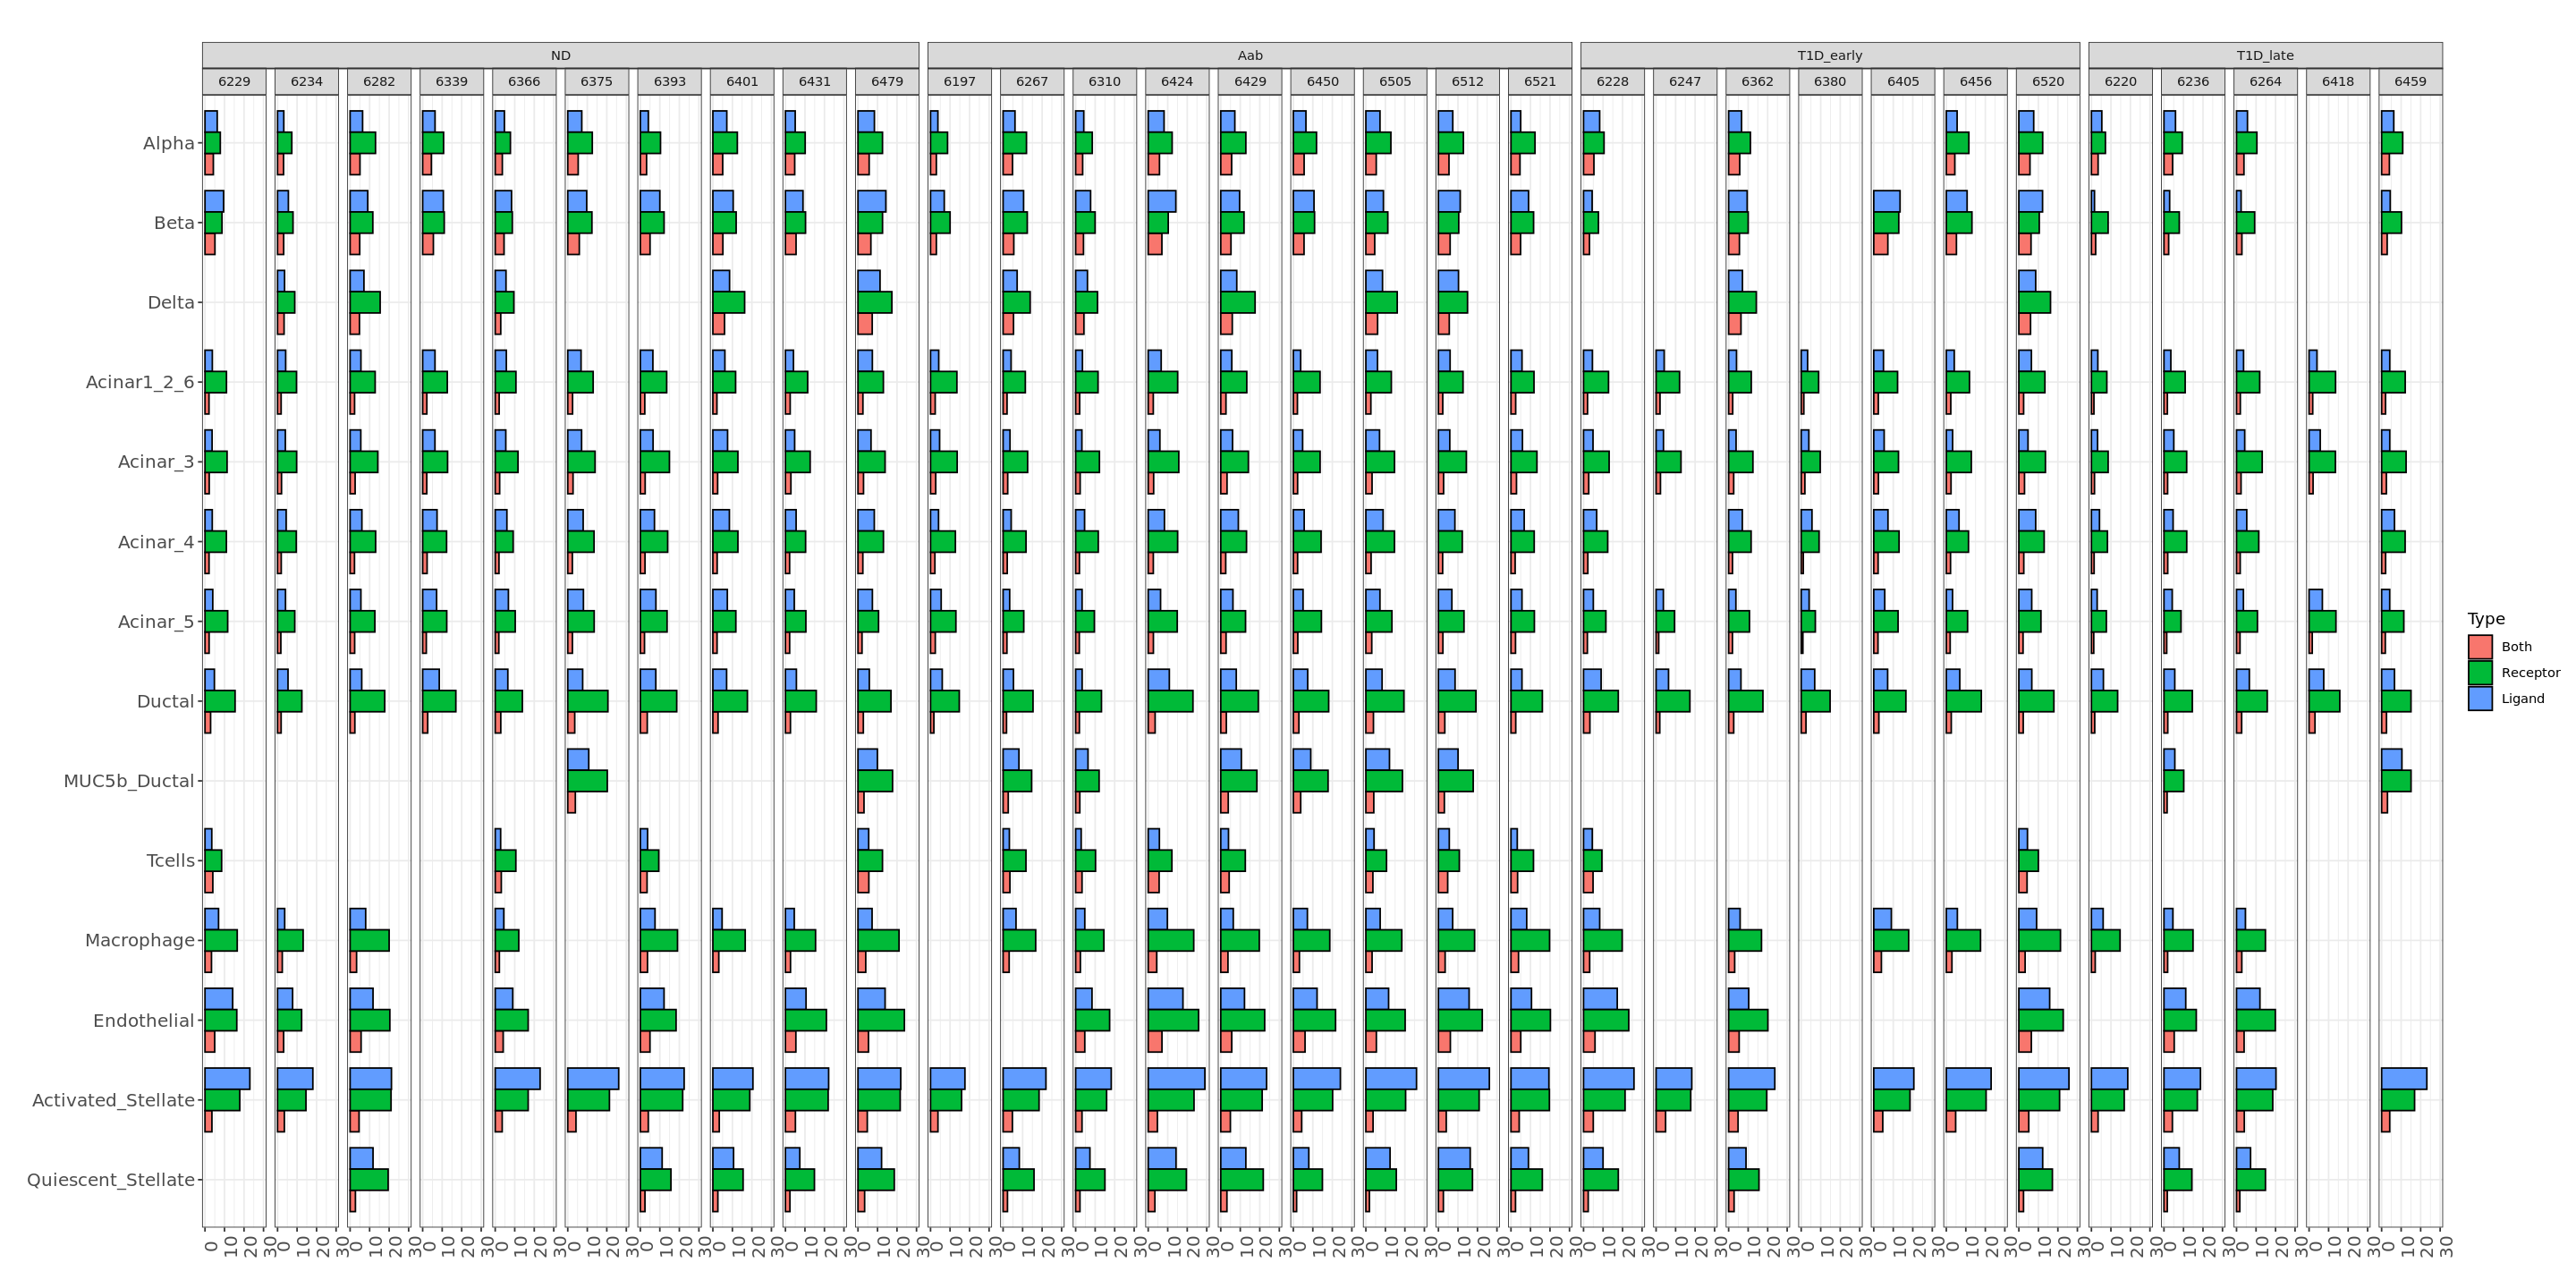

In [59]:
options(repr.plot.width=24, repr.plot.height=12)
ggplot(means.mat.aggregated, aes(x= cellpop, 
                                 y = Aggregated.avg.expression, 
                                 label = round(Aggregated.avg.expression, digits = 1),
                                 group_by = Sample,
                                 fill=Type)) +
       theme_bw () +
       geom_bar(stat="identity", colour="black", width = 0.8, 
                position = position_dodge(width = 0.8)) +
       labs(y= "", x = "", title = paste(""))+
       ylim(0,max)+
       theme(axis.text = element_text(size = 12), axis.title = element_text(size = 12, face = "bold"),
                  axis.text.x = element_text(angle = 90),
                             plot.title = element_text(size = 18, face = "bold", , hjust = 0.5)) +
coord_flip()+ 
facet_nested(cols = vars(Condition, Sample), scales = "free_y", space = "free_y")

# Mode of action

In [62]:
head(means.mat.summary)
means.mat = means.mat.summary

,gene,sample,condition,cellpop,mean,Type,Mode.of.Action,Functional.classification,Functional.sub.classification,Gene.Family
,<chr>,<int>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>
1,ACKR1,6197,Aab,Alpha,0,Receptor,,,,
2,ACKR1,6197,Aab,Beta,0,Receptor,,,,
3,ACKR1,6197,Aab,Acinar1_2_6,0,Receptor,,,,
4,ACKR1,6197,Aab,Acinar_3,0,Receptor,,,,
5,ACKR1,6197,Aab,Acinar_4,0,Receptor,,,,
6,ACKR1,6197,Aab,Acinar_5,0,Receptor,,,,


In [63]:
means.mat = means.mat.summary[means.mat.summary$Type == "Ligand",]
means.mat.aggregated <- aggregate(means.mat$mean, by=list(Type=means.mat$Mode.of.Action, 
                                                          Condition=means.mat$condition,
                                                          Sample = means.mat$sample, 
                                                          cellpop=means.mat$cellpop),FUN=sum)

colnames(means.mat.aggregated)[5] = "Aggregated.avg.expression"

means.mat.aggregated$cellpop = factor(means.mat.aggregated$cellpop, levels = rev.cell.pop.order)
means.mat.aggregated$Condition = factor(means.mat.aggregated$Condition, levels = condition.ls)
means.mat.aggregated$Type = factor(means.mat.aggregated$Type, levels = rev(c('Secreted Signaling',
                                                                             'Cell-Cell Contact',
                                                                             'ECM-Receptor')))

# Complete the Data.frame
means.mat.aggregated = means.mat.aggregated %>% complete(Type, nesting(cellpop, Sample, Condition), 
                                                                 fill = list(Aggregated.avg.expression = 0))

# Assign compartments
means.mat.aggregated$compartment = means.mat.aggregated$cellpop

means.mat.aggregated$compartment = ifelse(means.mat.aggregated$compartment %in%  Endocrine, "Endocrine", 
                 ifelse(means.mat.aggregated$compartment %in%  Exocrine, "Exocrine",
                        ifelse(means.mat.aggregated$compartment %in%  Immune, "Immune",
                               ifelse(means.mat.aggregated$compartment %in%  Endothelial, "Endothelial", "Stromal"))))

means.mat.aggregated$compartment = factor(means.mat.aggregated$compartment, levels = c('Endocrine','Exocrine','Immune','Endothelial', "Stromal"))
means.mat.aggregated = means.mat.aggregated[!is.na(means.mat.aggregated$compartment),]


head(means.mat.aggregated)

Type,cellpop,Sample,Condition,Aggregated.avg.expression,compartment
<fct>,<fct>,<int>,<fct>,<dbl>,<fct>
ECM-Receptor,Quiescent_Stellate,6228,T1D_early,5.796329,Stromal
ECM-Receptor,Quiescent_Stellate,6236,T1D_late,4.326724,Stromal
ECM-Receptor,Quiescent_Stellate,6264,T1D_late,3.043254,Stromal
ECM-Receptor,Quiescent_Stellate,6267,Aab,4.447047,Stromal
ECM-Receptor,Quiescent_Stellate,6282,ND,6.803253,Stromal
ECM-Receptor,Quiescent_Stellate,6310,Aab,4.334076,Stromal


In [64]:
max(means.mat.aggregated$Aggregated.avg.expression)
max = 20

[1] 18.10845

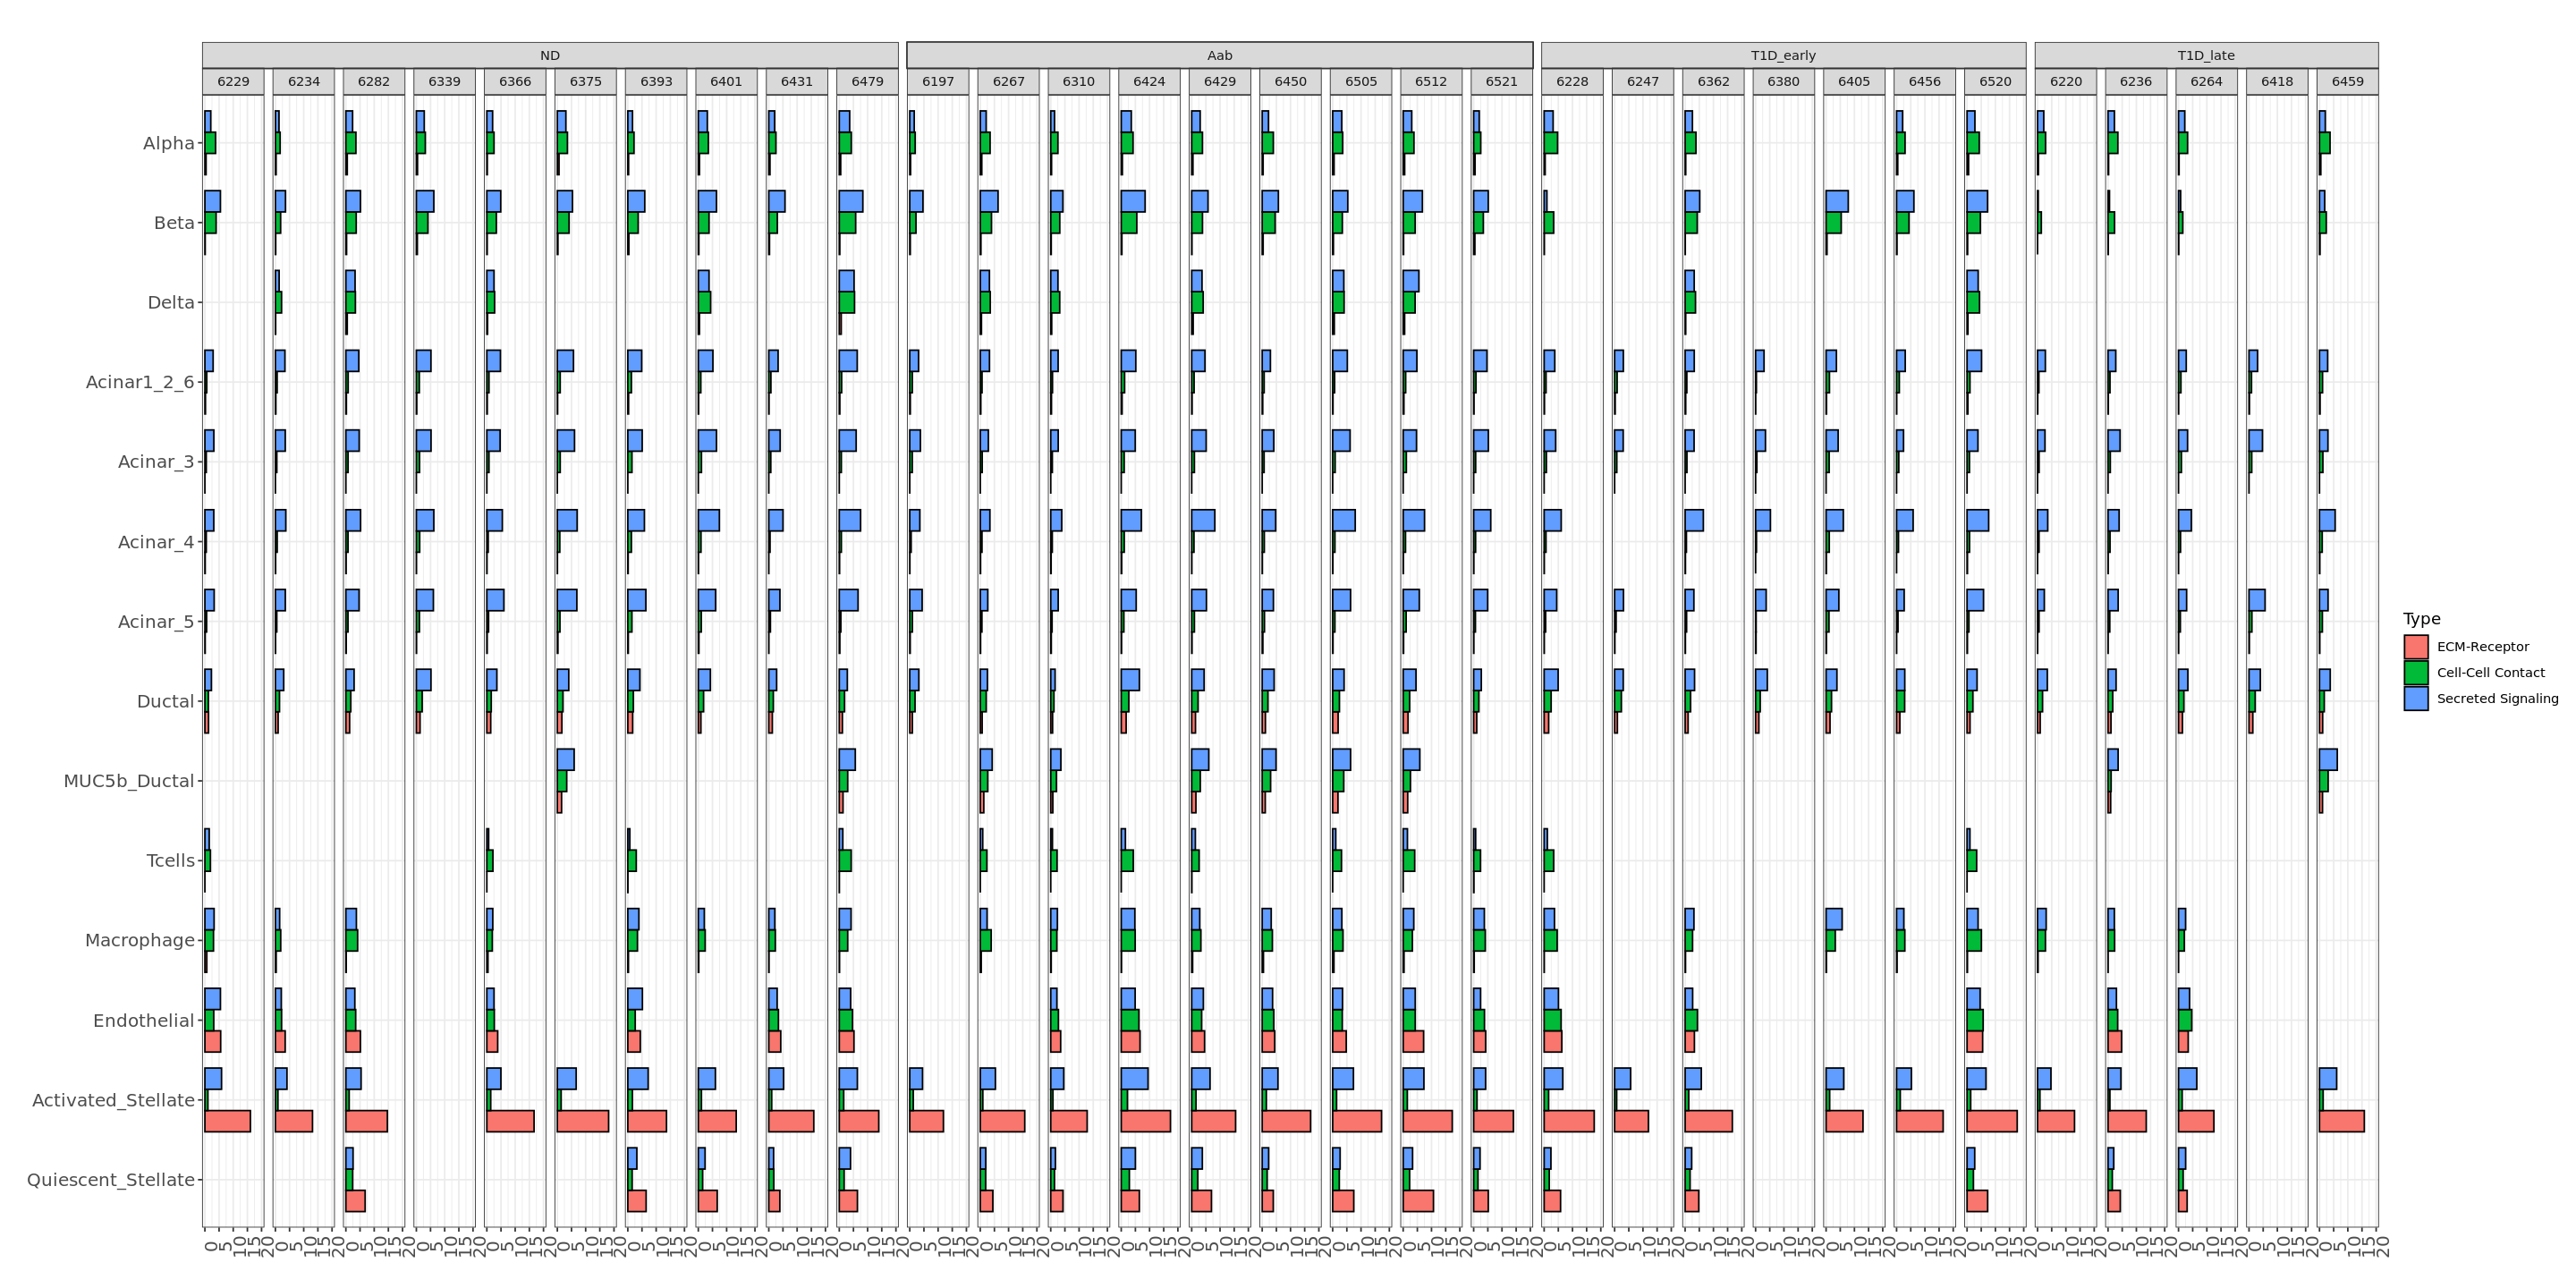

In [65]:
options(repr.plot.width=24, repr.plot.height=12)
ggplot(means.mat.aggregated, aes(x= cellpop, 
                                 y = Aggregated.avg.expression, 
                                 label = round(Aggregated.avg.expression, digits = 1),
                                 group_by = Sample,
                                 fill=Type)) +
       theme_bw () +
       geom_bar(stat="identity", colour="black", width = 0.8, 
                position = position_dodge(width = 0.8)) +
       labs(y= "", x = "", title = paste(""))+
       ylim(0,max)+
       theme(axis.text = element_text(size = 12), axis.title = element_text(size = 12, face = "bold"),
                  axis.text.x = element_text(angle = 90),
                             plot.title = element_text(size = 18, face = "bold", , hjust = 0.5)) +
coord_flip()+ 
facet_nested(cols = vars(Condition, Sample), scales = "free_y", space = "free_y")

# Functional classification

In [281]:
# Define signaling
Functional.classification.order = c('Hormones & Neuropeptides', 'Enzymes', 'Developmental Proteins', 
                                    'Growth Factors and Cytokines', 'Antigen-Presenting Molecules', 'Complement System',
                                    'Immune regulators', 'Modulators', 'Cell Adhesion Molecule', 'ECM Proteins')

In [207]:
    # Average ligand expression by sample
    means.mat.aggregated <- aggregate(means.mat$mean,
                            by=list(Functional.classification=means.mat$Functional.classification,
                                    sample = means.mat$sample,
                                    cellpop= means.mat$cellpop,
                                    condition = means.mat$condition),
                                    FUN=sum)
    colnames(means.mat.aggregated)[5] = "Aggregated.expression"
    means.mat.aggregated$cellpop = factor(means.mat.aggregated$cellpop, levels = rev.cell.pop.order)

In [208]:
    # Assign compartments
    means.mat.aggregated$compartment = means.mat.aggregated$cellpop

    means.mat.aggregated$compartment = ifelse(means.mat.aggregated$compartment %in%  Endocrine, "Endocrine", 
                     ifelse(means.mat.aggregated$compartment %in%  Exocrine, "Exocrine",
                            ifelse(means.mat.aggregated$compartment %in%  Immune, "Immune",
                                   ifelse(means.mat.aggregated$compartment %in%  Endothelial, "Endothelial", "Stromal"))))

    means.mat.aggregated$compartment = factor(means.mat.aggregated$compartment, levels = c('Endocrine','Exocrine','Immune','Endothelial', "Stromal"))
    means.mat.aggregated = means.mat.aggregated[!is.na(means.mat.aggregated$compartment),]
    means.mat.aggregated = na.omit(means.mat.aggregated)
        
    # Factorization and order factors
    means.mat.aggregated$condition = factor(means.mat.aggregated$condition, levels = rev(condition.ls))
    means.mat.aggregated$Functional.classification = factor(means.mat.aggregated$Functional.classification,
                                                            levels = Functional.classification.order)


## Visualization

In [211]:
means.mat.aggregated = filter(means.mat.aggregated,
                              Functional.classification != "Modulators" &
                              Functional.classification != "Cell Adhesion Molecule" &
                              Functional.classification != "ECM Proteins"
                             )

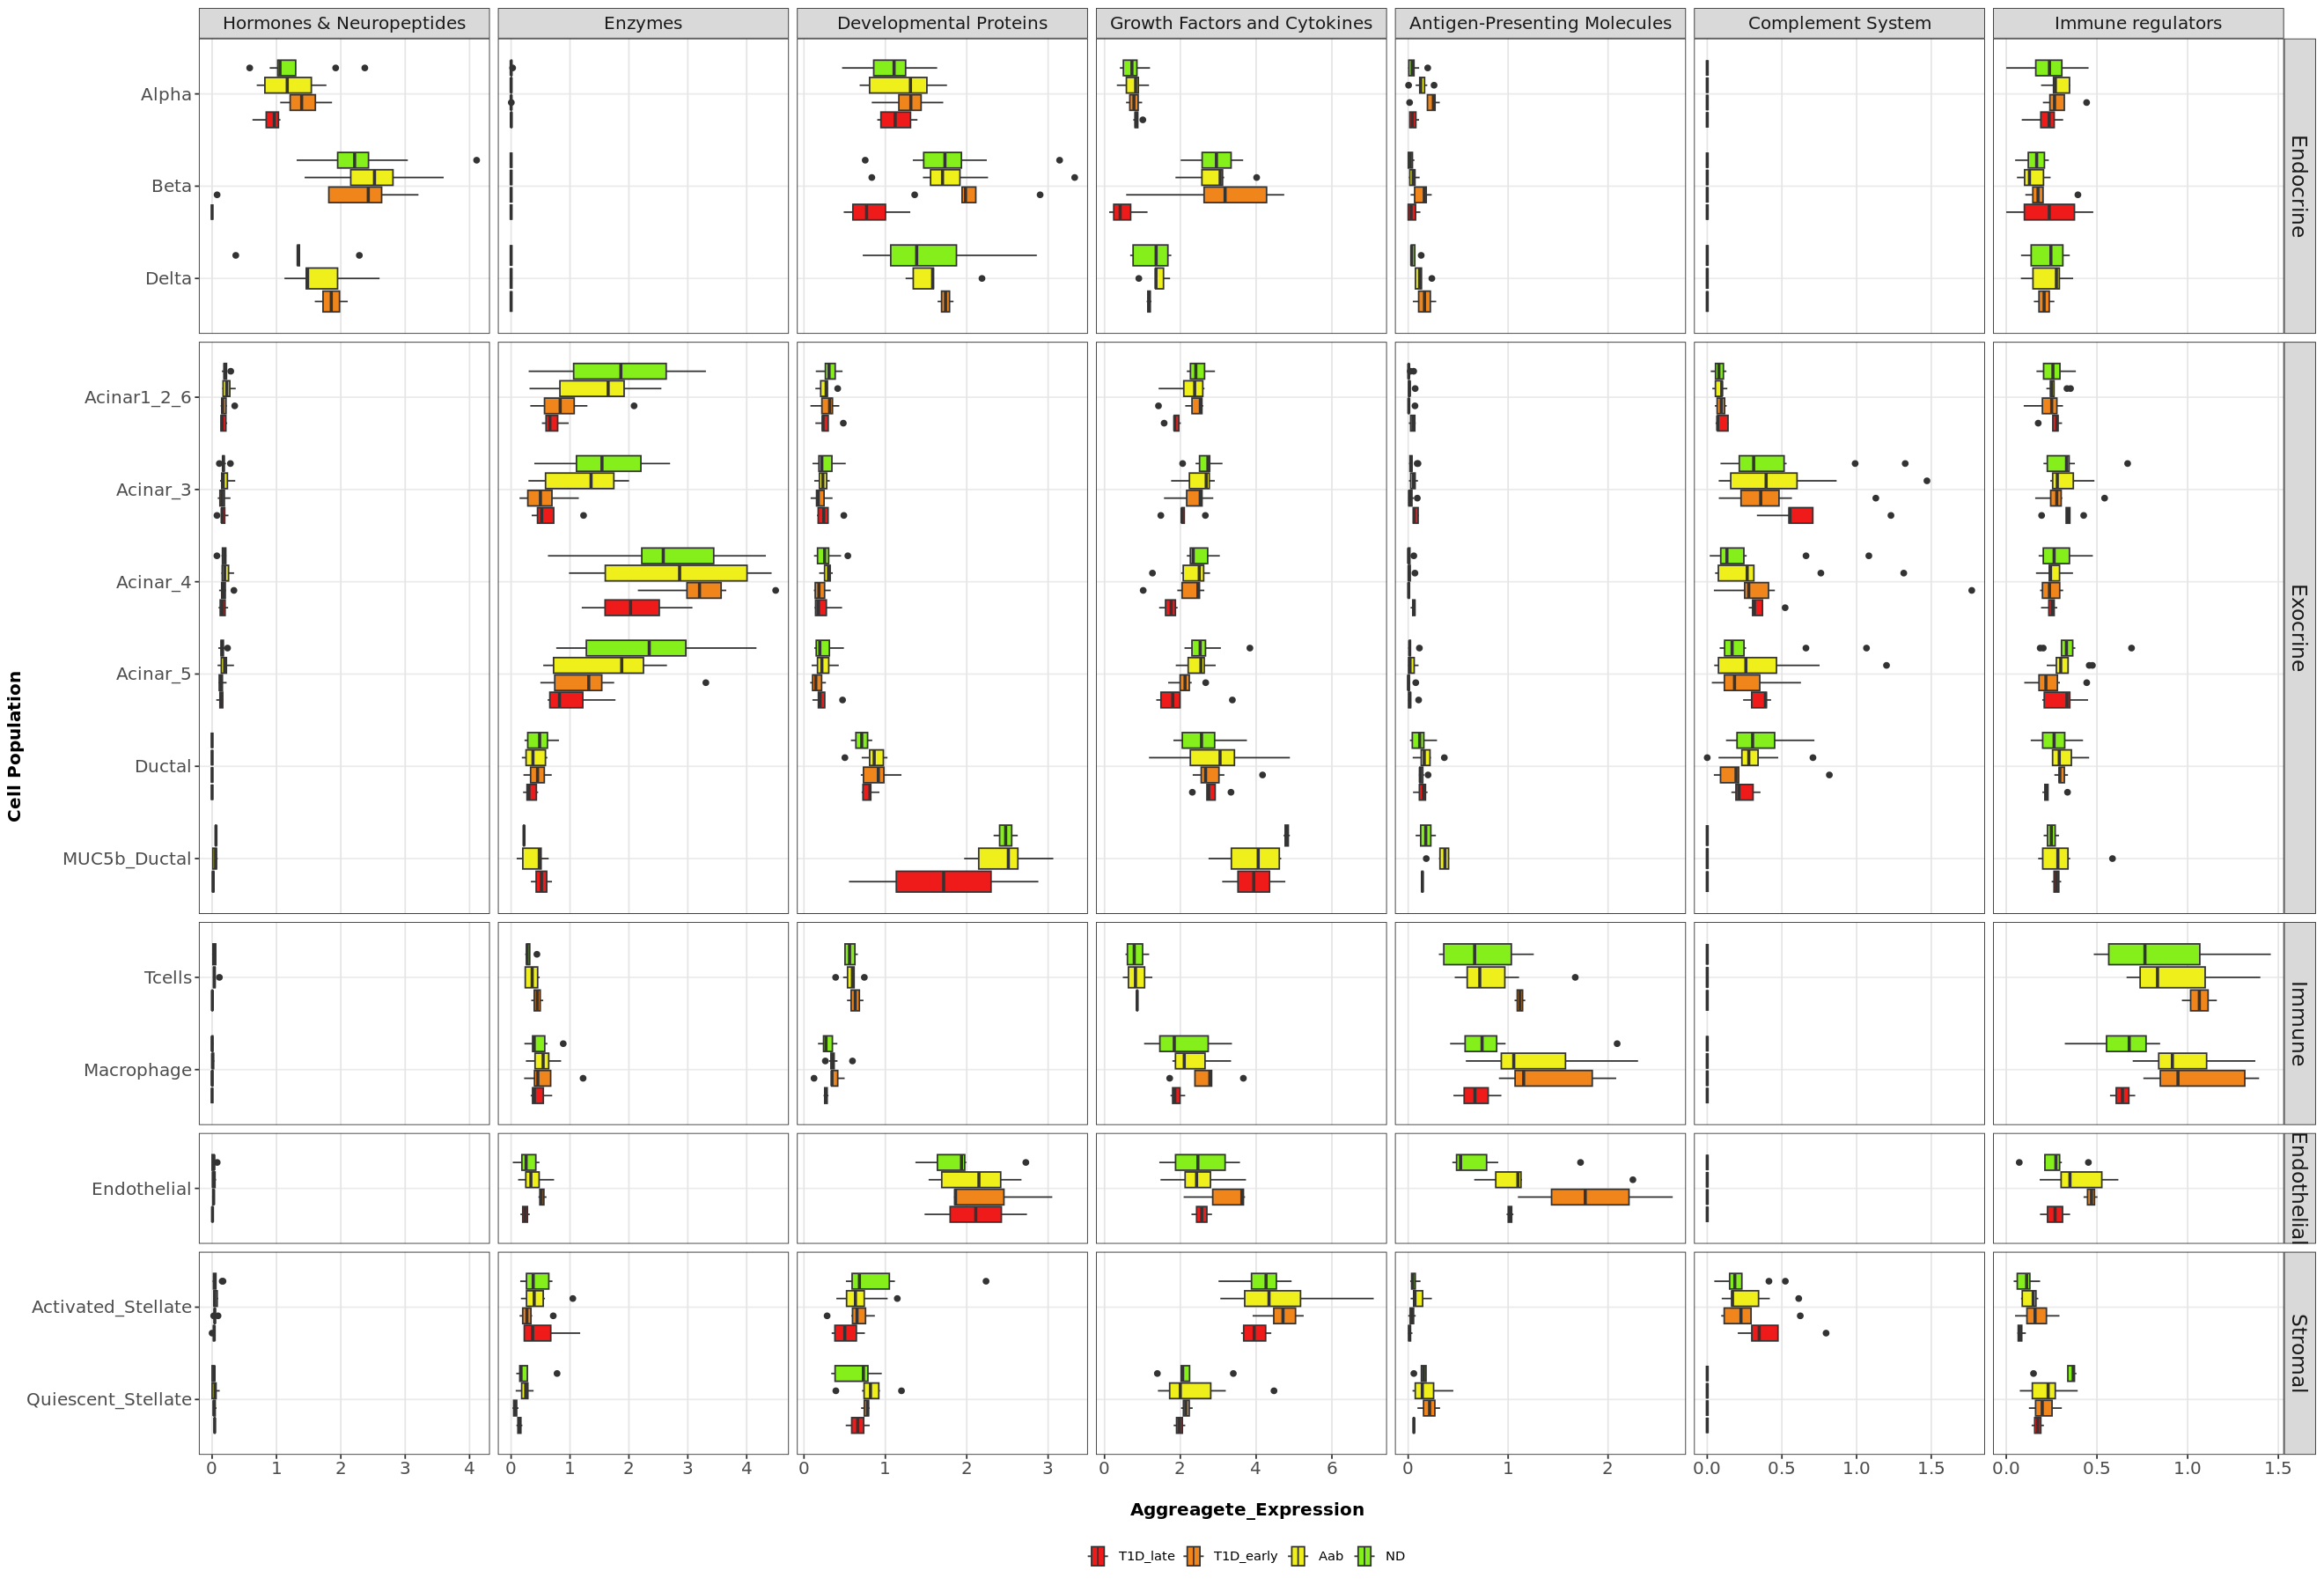

In [212]:
options(repr.plot.width=22, repr.plot.height=15)
ggplot(means.mat.aggregated, aes(x = Aggregated.expression, y = cellpop, fill = condition)) +
      geom_boxplot() +
      labs(x = "\n  Aggreagete_Expression", y = "Cell Population") +
      scale_fill_manual(values = colors.conditions) +
      theme_bw() +
      theme(axis.text = element_text(size = 12),
            axis.title = element_text(size = 12, face = "bold"),
            legend.title = element_blank(),
            legend.position = "bottom",
            strip.text.y = element_text(size = 14),
            strip.text.x = element_text(size = 12),
            plot.title = element_text(size = 18, face = "bold", hjust = 0.5),
            panel.grid.major.x = element_line(colour = "gray90"),
            panel.grid.minor.x = element_blank())+ 
    facet_nested(rows = vars(compartment), 
                 cols = vars(Functional.classification), 
                 scales = "free", space = "free_y")

In [222]:
head(means.mat.aggregated, n = 5)

,Functional.classification,sample,cellpop,condition,Aggregated.expression,compartment
,<fct>,<int>,<fct>,<fct>,<dbl>,<fct>
1,Antigen-Presenting Molecules,6197,Acinar_3,Aab,0.06925753,Exocrine
2,Complement System,6197,Acinar_3,Aab,0.10286716,Exocrine
3,Developmental Proteins,6197,Acinar_3,Aab,0.23173406,Exocrine
4,Enzymes,6197,Acinar_3,Aab,1.74442870,Exocrine
5,Growth Factors and Cytokines,6197,Acinar_3,Aab,1.75682868,Exocrine


In [269]:
# Assuming `df` is your dataframe

df_normalized <- means.mat.aggregated %>%
  group_by(Functional.classification, cellpop) %>%
  mutate(means_ND = mean(Aggregated.expression[condition == "ND"])) %>%
  ungroup() %>%
  group_by(Functional.classification, sample, cellpop) %>%
  mutate(FC = ifelse(condition == "ND", 
                     1, 
                     Aggregated.expression/means_ND)) %>%
  ungroup()

In [270]:
df_normalized$log2fc = log(df_normalized$FC, base = 2)

In [264]:
test = filter(df_normalized, 
       cellpop == "Acinar_3" &
      Functional.classification == "Antigen-Presenting Molecules")
test

Functional.classification,sample,cellpop,condition,Aggregated.expression,compartment,means_ND,FC
<fct>,<int>,<fct>,<fct>,<dbl>,<fct>,<dbl>,<dbl>
Antigen-Presenting Molecules,6197,Acinar_3,Aab,0.069257529,Exocrine,0.03796302,1.82434212
Antigen-Presenting Molecules,6267,Acinar_3,Aab,0.023398485,Exocrine,0.03796302,0.61634948
Antigen-Presenting Molecules,6310,Acinar_3,Aab,0.007522528,Exocrine,0.03796302,0.19815411
Antigen-Presenting Molecules,6424,Acinar_3,Aab,0.097379472,Exocrine,0.03796302,2.56511423
Antigen-Presenting Molecules,6429,Acinar_3,Aab,0.052368144,Exocrine,0.03796302,1.37945163
Antigen-Presenting Molecules,6450,Acinar_3,Aab,0.047992457,Exocrine,0.03796302,1.26418978
Antigen-Presenting Molecules,6505,Acinar_3,Aab,0.072781902,Exocrine,0.03796302,1.91717914
Antigen-Presenting Molecules,6512,Acinar_3,Aab,0.061509581,Exocrine,0.03796302,1.62025014
Antigen-Presenting Molecules,6521,Acinar_3,Aab,0.024825607,Exocrine,0.03796302,0.65394191


In [262]:
df_normalized <- means.mat.aggregated %>%
      group_by(cellpop, condition) %>%
      mutate(FC = sum(Aggregated.expression),
             source_proportion = Aggregated.expression/source_sum,
             zscore = scale(Aggregated.expression)) %>%
      ungroup()

ERROR: [1m[33mError[39m in `mutate()`:[22m
[1m[22m[33m![39m Problem while computing `source_proportion = Aggregated.expression/source_sum`.
[36mℹ[39m The error occurred in group 1: cellpop = Quiescent_Stellate, condition = T1D_late.
[1mCaused by error in `mask$eval_all_mutate()`:[22m
[33m![39m object 'source_sum' not found


Warning message:
“Removed 197 rows containing non-finite values (`stat_boxplot()`).”


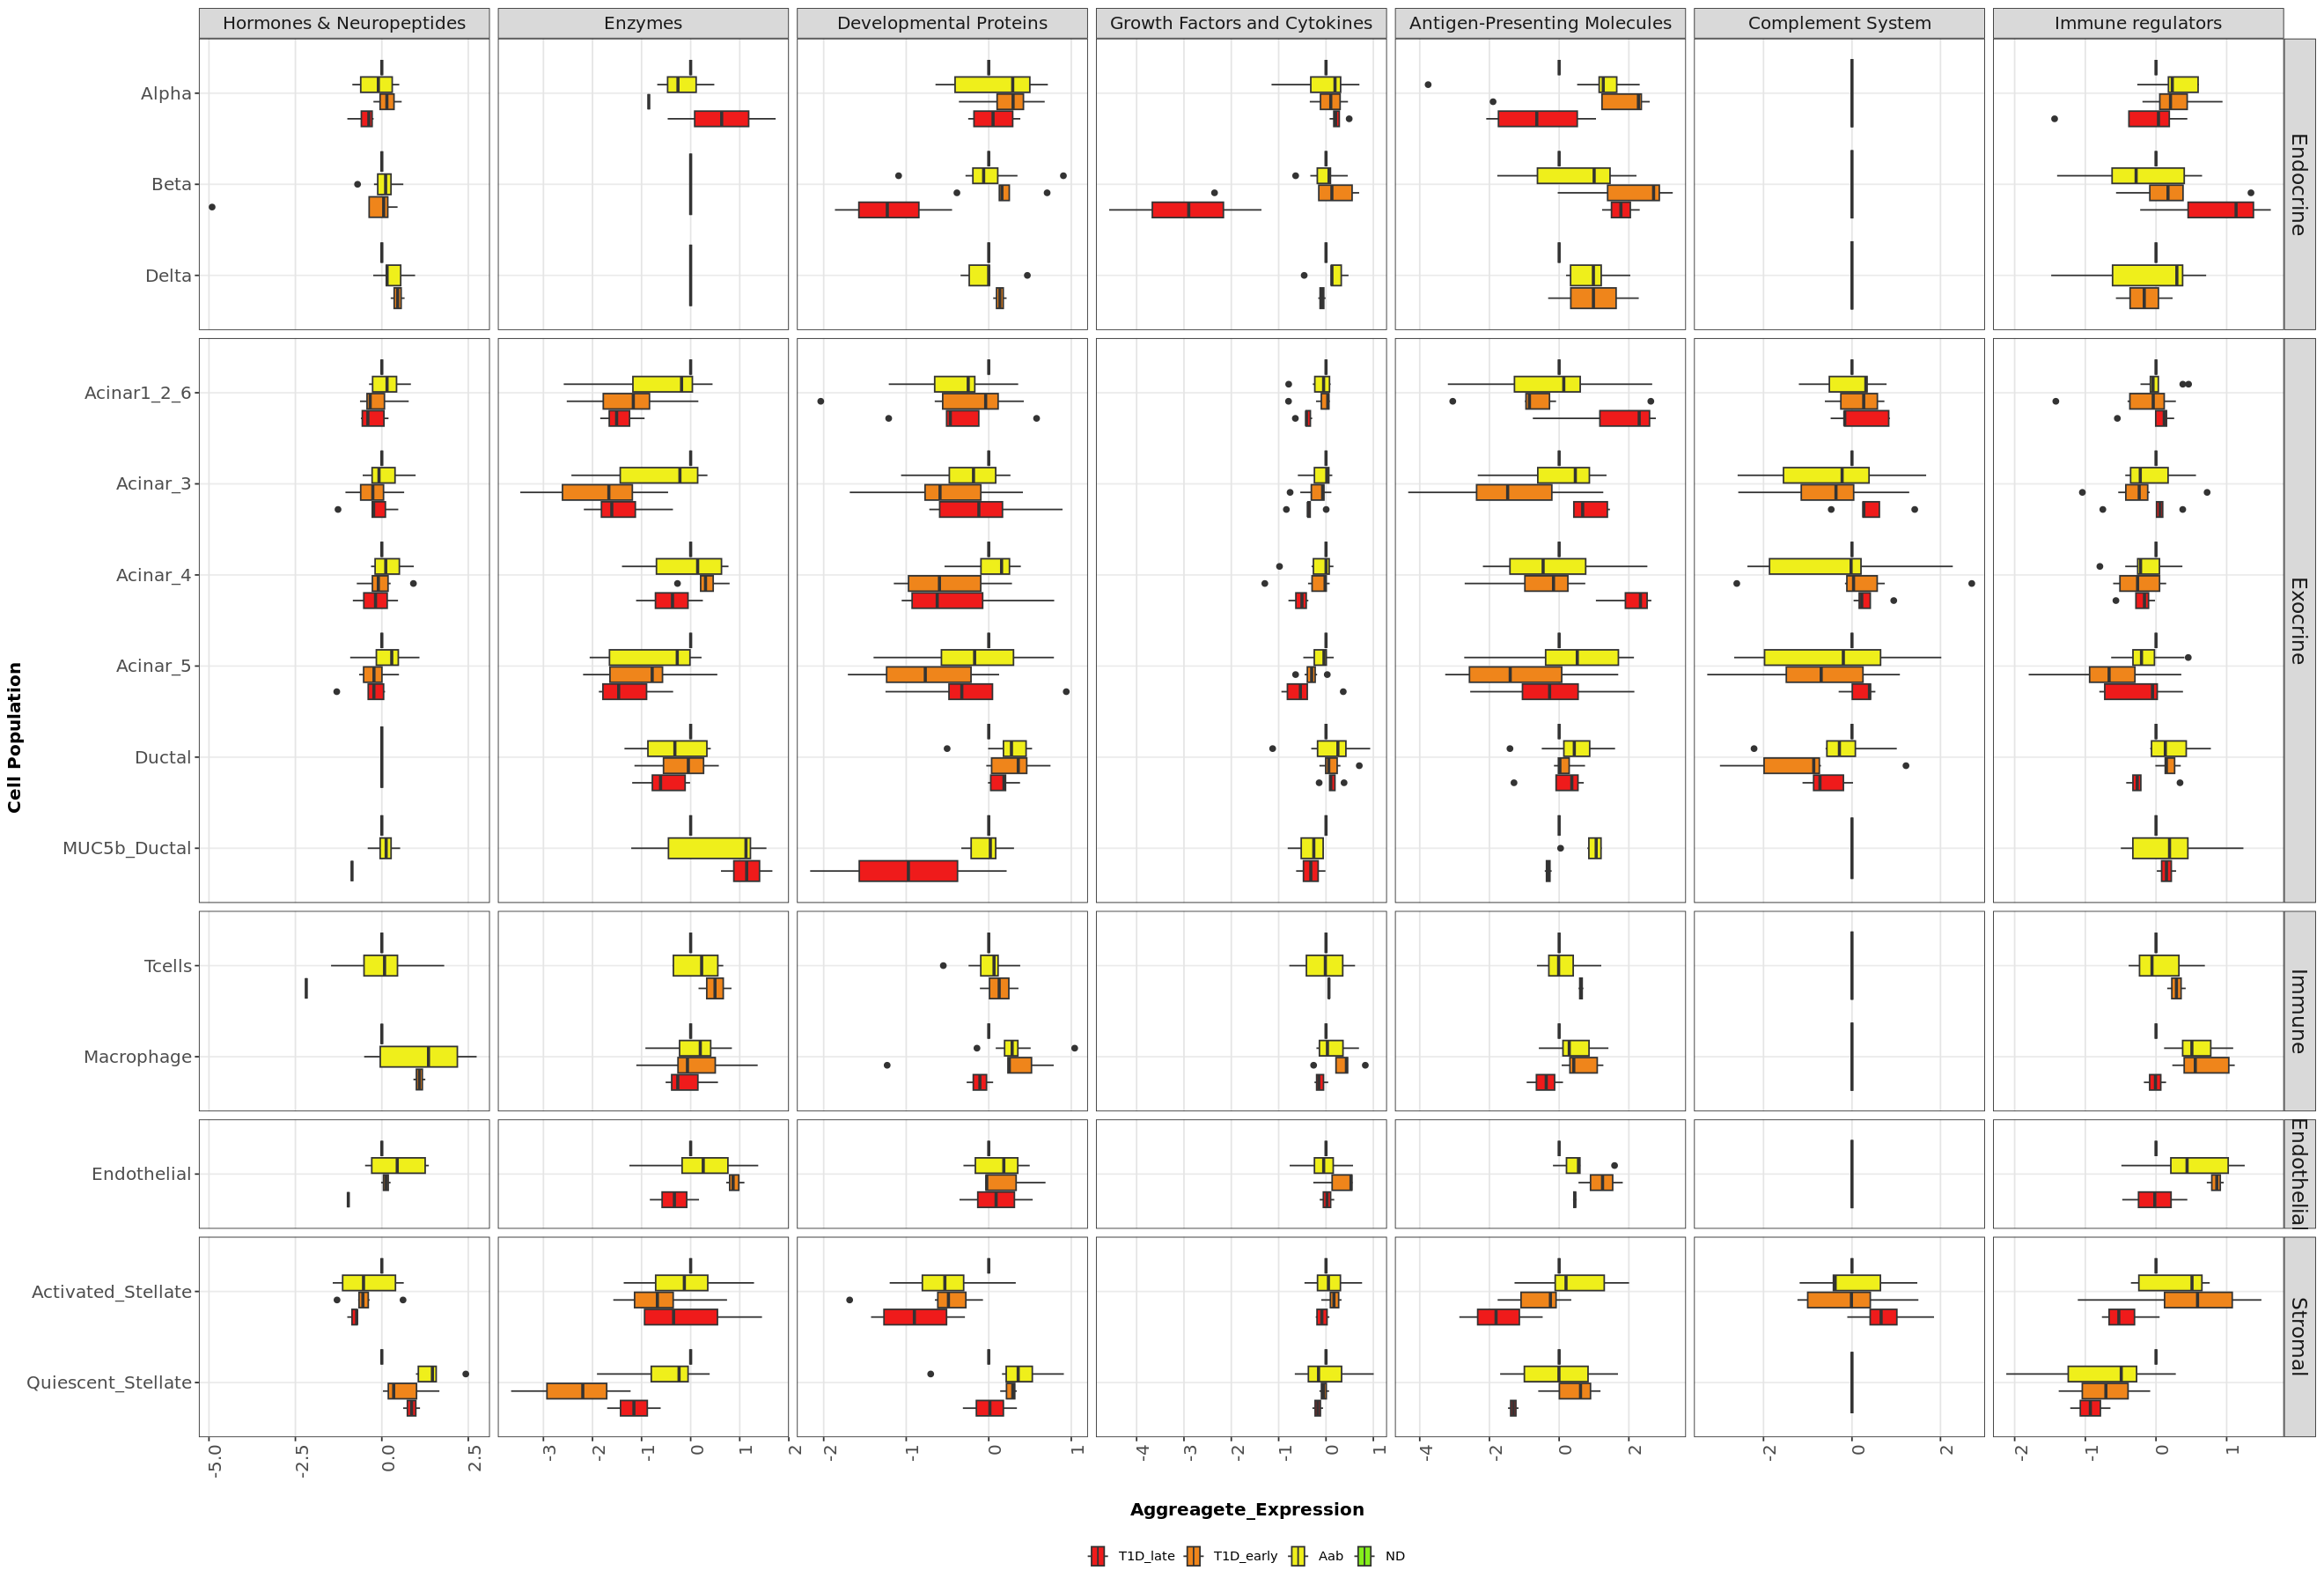

In [280]:
options(repr.plot.width=22, repr.plot.height=15)
ggplot(df_normalized, aes(x = log2fc, y = cellpop, fill = condition)) +
      geom_boxplot() +
      labs(x = "\n  Aggreagete_Expression", y = "Cell Population") +
      scale_fill_manual(values = colors.conditions) +
      theme_bw() +
      theme(axis.text = element_text(size = 12),
            axis.title = element_text(size = 12, face = "bold"),
            legend.title = element_blank(),
            legend.position = "bottom",
            axis.text.x = element_text(angle = 90, hjust = 1),
            strip.text.y = element_text(size = 14),
            strip.text.x = element_text(size = 12),
            plot.title = element_text(size = 18, face = "bold", hjust = 0.5),
            panel.grid.major.x = element_line(colour = "gray90"),
            panel.grid.minor.x = element_blank())+ 
    facet_nested(rows = vars(compartment), 
                 cols = vars(Functional.classification), 
                 scales = "free", space = "free_y")

## Test

Beta - Hormones & Neuropeptides




	Shapiro-Wilk normality test

data:  resid(res.aov)
W = 0.95728, p-value = 0.3001


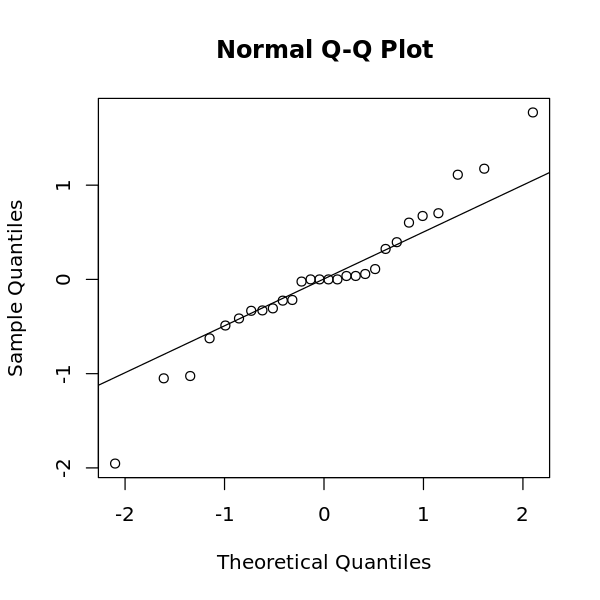

In [194]:
# Check specific stuff    
    cell.pop = "Beta"
    term = "Hormones & Neuropeptides"
    message(cell.pop, " - ", term)
    # Subset data
    data_subset = filter(means.mat.aggregated, 
                          cellpop == cell.pop & Functional.classification == term)
    
    # Check if all values in data_subset$Aggregated.expression are 0
    if(all(data_subset$Aggregated.expression == 0)){
        message("All Aggregated.expression values for ", cell.pop, " - ", term, " are 0. Skipping...")
        next
    }
    # Perform kruskal.test
    kruskal.test = kruskal.test(Aggregated.expression ~ condition, data = data_subset)
    kruskal$p.value = kruskal.test$p.value
    kruskal$term = term
    kruskal$cellpop = cell.pop
    
    # Perform the Dunn test
    dun.res <- dunnTest(Aggregated.expression ~ condition, data = data_subset, method="bh")
    dun.res = filter(dun.res$res, 
                      Comparison %in% c("Aab - ND", "ND - T1D_early", "ND - T1D_late"))
    dun.res$term = term
    dun.res$cellpop = cell.pop
    
    # Perform one way anova
    aov.res = aov(Aggregated.expression ~ condition, data = data_subset)
    tukey.res = TukeyHSD(aov.res)
    aov.res = broom::tidy(aov.res)
    aov.res = aov.res[1,]
    aov.res$term = term
    aov.res$cellpop = cell.pop
    
    # Perform multiple comparisons
    tukey.res = broom::tidy(tukey.res)
    tukey.res = filter(tukey.res, contrast %in% c("ND-Aab", "ND-T1D_early", "ND-T1D_late"))
    tukey.res$term = term
    tukey.res$cellpop = cell.pop
    
    # check normality of the data -> if NS is normal 
    options(repr.plot.width=5, repr.plot.height=5)
    res.aov <- aov(Aggregated.expression ~ condition, data = data_subset)
    qqnorm(resid(res.aov))
    qqline(resid(res.aov))

    shapiro.test(resid(res.aov))

In [195]:
kruskal = NULL
kruskal.res.all = data.frame()
dun.res.all = data.frame()

aov.res = NULL
aov.res.all = data.frame()
tukey.res.all = data.frame()

combos <- unique(means.mat.aggregated[,c("cellpop", "Functional.classification")])

for (i in seq_len(nrow(combos))){
    cell.pop = as.character(combos$cellpop[i])
    term = as.character(combos$Functional.classification[i])
    message(cell.pop, " - ", term)
    # Subset data
    data_subset = filter(means.mat.aggregated, 
                          cellpop == cell.pop & Functional.classification == term)
    
    # Check if all values in data_subset$Aggregated.expression are 0
    if(all(data_subset$Aggregated.expression == 0)){
        message("All Aggregated.expression values for ", cell.pop, " - ", term, " are 0. Skipping...")
        next
    }
    # Perform kruskal.test
    kruskal.test = kruskal.test(Aggregated.expression ~ condition, data = data_subset)
    kruskal$p.value = kruskal.test$p.value
    kruskal$term = term
    kruskal$cellpop = cell.pop
    kruskal.res.all = rbind(kruskal.res.all, kruskal)
    
    # Perform the Dunn test
    dun.res <- dunnTest(Aggregated.expression ~ condition, data = data_subset, method="bh")
    dun.res = filter(dun.res$res, 
                      Comparison %in% c("Aab - ND", "ND - T1D_early", "ND - T1D_late"))
    dun.res$term = term
    dun.res$cellpop = cell.pop
    dun.res.all = rbind(dun.res.all, dun.res)
    
    # Perform one way anova
    aov.res = aov(Aggregated.expression ~ condition, data = data_subset)
    tukey.res = TukeyHSD(aov.res)
    aov.res = broom::tidy(aov.res)
    aov.res = aov.res[1,]
    aov.res$term = term
    aov.res$cellpop = cell.pop
    aov.res.all = rbind(aov.res.all, aov.res)
    
    # Perform multiple comparisons
    tukey.res = broom::tidy(tukey.res)
    tukey.res = filter(tukey.res, contrast %in% c("ND-Aab", "ND-T1D_early", "ND-T1D_late"))
    tukey.res$term = term
    tukey.res$cellpop = cell.pop
    tukey.res.all = rbind(tukey.res.all, tukey.res)
}

Acinar_3 - Antigen-Presenting Molecules

Acinar_3 - Complement System

Acinar_3 - Developmental Proteins

Acinar_3 - Enzymes

Acinar_3 - Growth Factors and Cytokines

Acinar_3 - Hormones & Neuropeptides

Acinar_3 - Immune regulators

Acinar_4 - Antigen-Presenting Molecules

Acinar_4 - Complement System

Acinar_4 - Developmental Proteins

Acinar_4 - Enzymes

Acinar_4 - Growth Factors and Cytokines

Acinar_4 - Hormones & Neuropeptides

Acinar_4 - Immune regulators

Acinar_5 - Antigen-Presenting Molecules

Acinar_5 - Complement System

Acinar_5 - Developmental Proteins

Acinar_5 - Enzymes

Acinar_5 - Growth Factors and Cytokines

Acinar_5 - Hormones & Neuropeptides

Acinar_5 - Immune regulators

Acinar1_2_6 - Antigen-Presenting Molecules

Acinar1_2_6 - Complement System

Acinar1_2_6 - Developmental Proteins

Acinar1_2_6 - Enzymes

Acinar1_2_6 - Growth Factors and Cytokines

Acinar1_2_6 - Hormones & Neuropeptides

Acinar1_2_6 - Immune regulators

Activated_Stellate - Antigen-Presenting Mol

In [196]:
filter(aov.res.all, p.value < 0.1)
filter(tukey.res.all, adj.p.value < 0.1)

term,df,sumsq,meansq,statistic,p.value,cellpop
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
Antigen-Presenting Molecules,3,0.006758456,0.002252819,2.492326,0.0814441587,Acinar_3
Enzymes,3,5.677491851,1.892497284,4.775403,0.0085048428,Acinar_3
Growth Factors and Cytokines,3,1.215353080,0.405117693,2.729175,0.0635290407,Acinar_3
Antigen-Presenting Molecules,3,0.006303018,0.002101006,6.634418,0.0018910353,Acinar_4
Growth Factors and Cytokines,3,1.804986111,0.601662037,3.138565,0.0431298306,Acinar_4
Enzymes,3,6.324631171,2.108210390,2.474163,0.0830208984,Acinar_5
Antigen-Presenting Molecules,3,0.004344187,0.001448062,3.066429,0.0448427085,Acinar1_2_6
Enzymes,3,6.114935861,2.038311954,3.104739,0.0431208315,Acinar1_2_6
Growth Factors and Cytokines,3,1.291064050,0.430354683,3.869774,0.0200904770,Acinar1_2_6


term,contrast,null.value,estimate,conf.low,conf.high,adj.p.value,cellpop
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
Enzymes,ND-T1D_late,0,0.92608949,-0.017490713,1.869669686,0.0558227589,Acinar_3
Enzymes,ND-T1D_early,0,1.04539137,0.196418853,1.894363890,0.0115053659,Acinar_3
Growth Factors and Cytokines,ND-T1D_late,0,0.58662667,0.009141162,1.164112172,0.0454646238,Acinar_3
Antigen-Presenting Molecules,ND-T1D_late,0,-0.04209685,-0.071055650,-0.013138050,0.0026268165,Acinar_4
Growth Factors and Cytokines,ND-T1D_late,0,0.77571509,0.063224603,1.488205569,0.0291939005,Acinar_4
Enzymes,ND-T1D_late,0,1.25184664,-0.131748566,2.635441854,0.0867686837,Acinar_5
Antigen-Presenting Molecules,ND-T1D_late,0,-0.03420173,-0.066773646,-0.001629808,0.0369060403,Acinar1_2_6
Enzymes,ND-T1D_late,0,1.16470818,-0.049767827,2.379184196,0.0636733737,Acinar1_2_6
Growth Factors and Cytokines,ND-T1D_late,0,0.61636123,0.116514695,1.116207759,0.0113726213,Acinar1_2_6


# Functional sub-classification

In [156]:
    # Average ligand expression by sample
    means.mat.aggregated <- aggregate(means.mat$mean,
                            by=list(Functional.sub.classification=means.mat$Functional.sub.classification,
                                    Functional.classification=means.mat$Functional.classification,
                                    sample = means.mat$sample,
                                    cellpop= means.mat$cellpop,
                                    condition = means.mat$condition),
                                    FUN=sum)
    colnames(means.mat.aggregated)[6] = "Aggregated.expression"
    means.mat.aggregated$cellpop = factor(means.mat.aggregated$cellpop, levels = rev.cell.pop.order)

In [157]:
    # Assign compartments
    means.mat.aggregated$compartment = means.mat.aggregated$cellpop

    means.mat.aggregated$compartment = ifelse(means.mat.aggregated$compartment %in%  Endocrine, "Endocrine", 
                     ifelse(means.mat.aggregated$compartment %in%  Exocrine, "Exocrine",
                            ifelse(means.mat.aggregated$compartment %in%  Immune, "Immune",
                                   ifelse(means.mat.aggregated$compartment %in%  Endothelial, "Endothelial", "Stromal"))))

    means.mat.aggregated$compartment = factor(means.mat.aggregated$compartment, levels = c('Endocrine','Exocrine','Immune','Endothelial', "Stromal"))
    means.mat.aggregated = means.mat.aggregated[!is.na(means.mat.aggregated$compartment),]
    means.mat.aggregated = na.omit(means.mat.aggregated)
        
    # Factorization and order factors
    means.mat.aggregated$condition = factor(means.mat.aggregated$condition, levels = rev(condition.ls))
    means.mat.aggregated$Functional.classification = factor(means.mat.aggregated$Functional.classification,
                                                            levels = Functional.classification.order)


In [158]:
filter(means.mat.aggregated, cellpop == "Beta" &
       Functional.classification == "Hormones & Neuropeptides")

Functional.sub.classification,Functional.classification,sample,cellpop,condition,Aggregated.expression,compartment
<chr>,<fct>,<int>,<fct>,<fct>,<dbl>,<fct>
Hormone (Adipose Tissue),Hormones & Neuropeptides,6197,Beta,Aab,0.000000000,Endocrine
Hormone (Brain),Hormones & Neuropeptides,6197,Beta,Aab,0.000000000,Endocrine
Hormone (Colon),Hormones & Neuropeptides,6197,Beta,Aab,0.000000000,Endocrine
Hormone (Heart),Hormones & Neuropeptides,6197,Beta,Aab,0.000000000,Endocrine
Hormone (Kidney),Hormones & Neuropeptides,6197,Beta,Aab,0.000000000,Endocrine
Hormone (Liver),Hormones & Neuropeptides,6197,Beta,Aab,0.003591436,Endocrine
Hormone (Musculoskeletal System),Hormones & Neuropeptides,6197,Beta,Aab,0.000000000,Endocrine
Hormone (Pancreas),Hormones & Neuropeptides,6197,Beta,Aab,2.519829442,Endocrine
Hormone (Parathyroid Gland),Hormones & Neuropeptides,6197,Beta,Aab,0.000000000,Endocrine


## Visualization

In [159]:
# Define signaling
Functional.classification.order = c('Hormones & Neuropeptides', 'Enzymes', 'Developmental Proteins', 
                                    'Growth Factors and Cytokines', 'Antigen-Presenting Molecules', 'Complement System',
                                    'Immune regulators', 'Modulators', 'Cell Adhesion Molecule', 'ECM Proteins')

In [154]:
means.mat.aggregated.use = filter(means.mat.aggregated,
                                  Functional.classification == "Hormones & Neuropeptides")

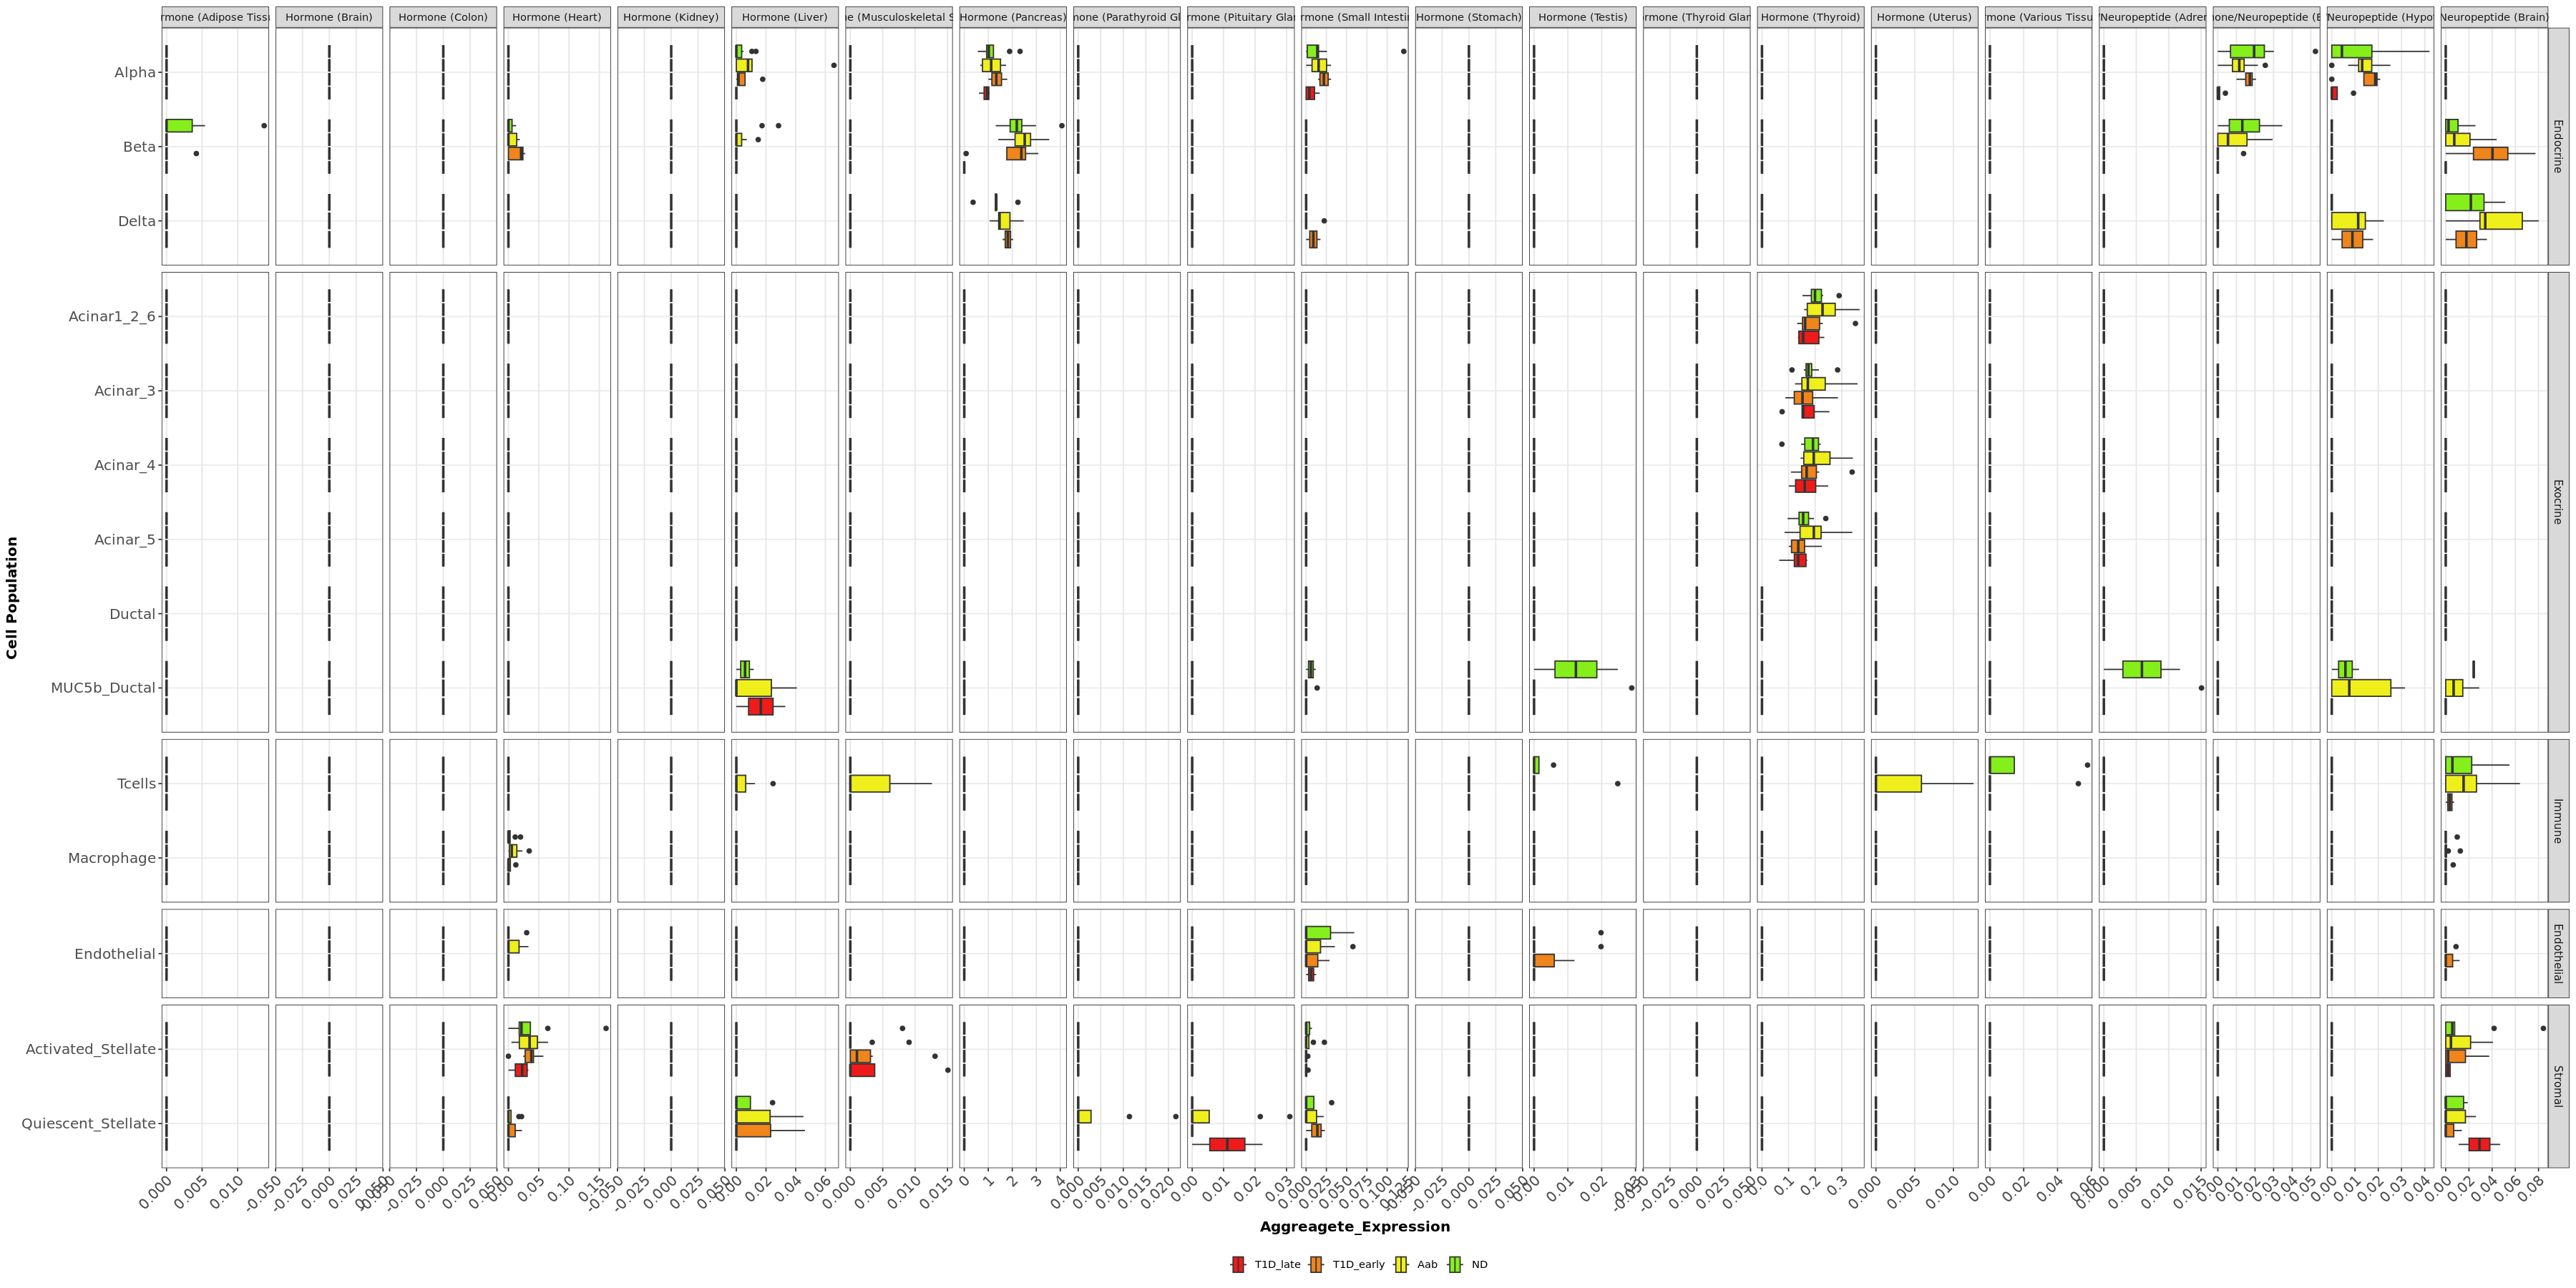

In [155]:
options(repr.plot.width=30, repr.plot.height=15)
ggplot(means.mat.aggregated.use, aes(x = Aggregated.expression, y = cellpop, fill = condition)) +
      geom_boxplot() +
      labs(x = "Aggreagete_Expression", y = "Cell Population") +
      scale_fill_manual(values = colors.conditions) +
      theme_bw() +
      theme(axis.text = element_text(size = 12),
            axis.text.x = element_text(angle = 45, hjust = 1),
            axis.title = element_text(size = 12, face = "bold"),
            legend.title = element_blank(),
            legend.position = "bottom",
            strip.text.y = element_text(size = 9),
            plot.title = element_text(size = 18, face = "bold", hjust = 0.5),
            panel.grid.major.x = element_line(colour = "gray90"),
            panel.grid.minor.x = element_blank())+ 
    facet_nested(rows = vars(compartment), 
                 cols = vars(Functional.sub.classification), 
                 scales = "free", space = "free_y")

In [161]:
Functional.classification.order

[1] "Hormones & Neuropeptides"     "Enzymes"                     
 [3] "Developmental Proteins"       "Growth Factors and Cytokines"
 [5] "Antigen-Presenting Molecules" "Complement System"           
 [7] "Immune regulators"            "Modulators"                  
 [9] "Cell Adhesion Molecule"       "ECM Proteins"

In [180]:
test = filter(means.mat.aggregated, cellpop == "Beta" &
              Functional.classification == Functional.classification.order[7])
test$condition = factor(test$condition, levels = condition.ls)

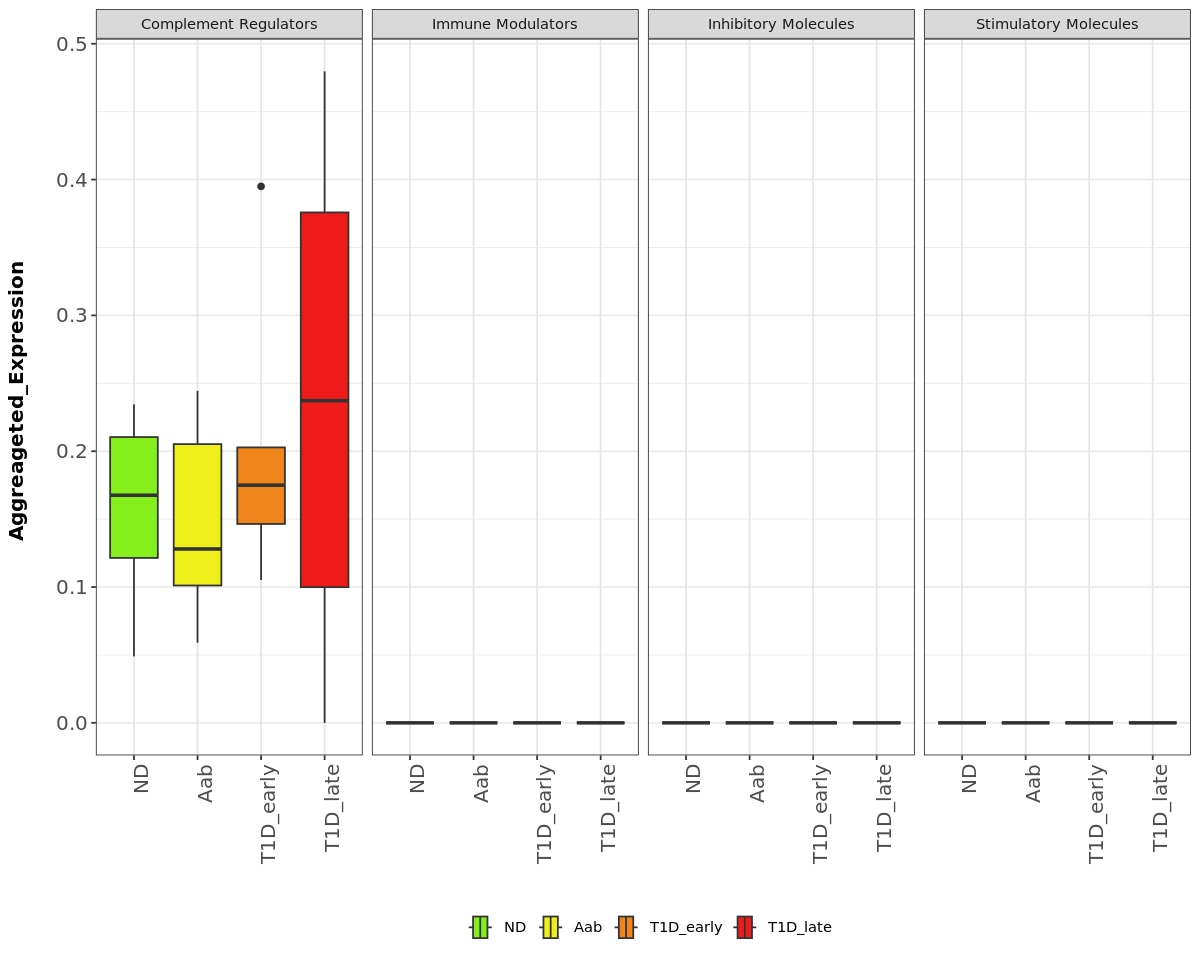

In [181]:
options(repr.plot.width=10, repr.plot.height=8)
ggplot(test, aes(x = Aggregated.expression, y = condition, fill = condition)) +
      geom_boxplot() +
      labs(x = "Aggreageted_Expression \n", y = "") +
      scale_fill_manual(values = colors.conditions) +
      theme_bw() +
      theme(axis.text = element_text(size = 12),
            axis.text.x = element_text(angle = 90, hjust = 1),
            axis.title = element_text(size = 12, face = "bold"),
            legend.title = element_blank(),
            legend.position = "bottom",
            strip.text.y = element_text(size = 8),
            plot.title = element_text(size = 18, face = "bold", hjust = 0.5),
            panel.grid.major.x = element_line(colour = "gray90"),
            panel.grid.minor.x = element_blank())+ 
            coord_flip()+
    facet_nested(cols = vars(Functional.sub.classification), 
                 scales = "fixed", space = "free_y")

## Test

Beta - Interleukins




	Shapiro-Wilk normality test

data:  resid(res.aov)
W = 0.97305, p-value = 0.6642


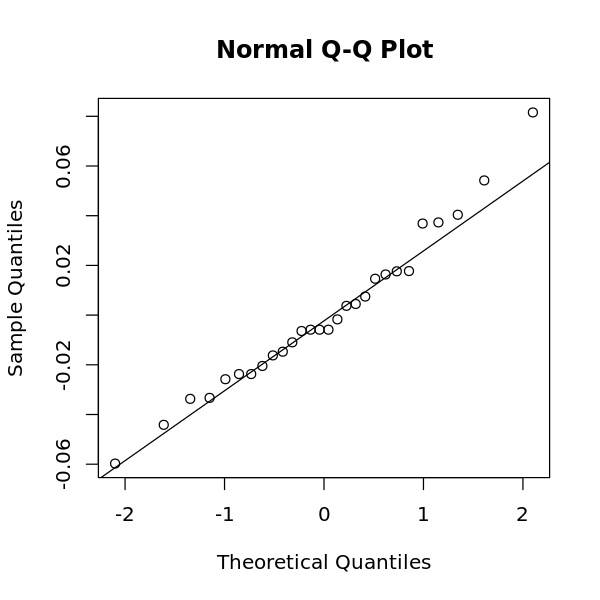

In [636]:
# Check specific stuff    
    cell.pop = "Beta"
    term = "Interleukins"
    message(cell.pop, " - ", term)
    # Subset data
    data_subset = filter(means.mat.aggregated, 
                          cellpop == cell.pop & Functional.sub.classification == term)
    
    # Check if all values in data_subset$Aggregated.expression are 0
    if(all(data_subset$Aggregated.expression == 0)){
        message("All Aggregated.expression values for ", cell.pop, " - ", term, " are 0. Skipping...")
        next
    }
    # Perform kruskal.test
    kruskal.test = kruskal.test(Aggregated.expression ~ condition, data = data_subset)
    kruskal$p.value = kruskal.test$p.value
    kruskal$term = term
    kruskal$cellpop = cell.pop
    kruskal.res.all = rbind(kruskal.res.all, kruskal)
    
    # Perform the Dunn test
    dun.res <- dunnTest(Aggregated.expression ~ condition, data = data_subset, method="bh")
    dun.res = filter(dun.res$res, 
                      Comparison %in% c("Aab - ND", "ND - T1D_early", "ND - T1D_late"))
    dun.res$term = term
    dun.res$cellpop = cell.pop
    dun.res.all = rbind(dun.res.all, dun.res)
    
    # Perform one way anova
    aov.res = aov(Aggregated.expression ~ condition, data = data_subset)
    tukey.res = TukeyHSD(aov.res)
    aov.res = broom::tidy(aov.res)
    aov.res = aov.res[1,]
    aov.res$term = term
    aov.res$cellpop = cell.pop
    aov.res.all = rbind(aov.res.all, aov.res)
    
    # Perform multiple comparisons
    tukey.res = broom::tidy(tukey.res)
    tukey.res = filter(tukey.res, contrast %in% c("ND-Aab", "ND-T1D_early", "ND-T1D_late"))
    tukey.res$term = term
    tukey.res$cellpop = cell.pop
    tukey.res.all = rbind(tukey.res.all, tukey.res)
    
    # check normality of the data -> if NS is normal 
    options(repr.plot.width=5, repr.plot.height=5)
    res.aov <- aov(Aggregated.expression ~ condition, data = data_subset)
    qqnorm(resid(res.aov))
    qqline(resid(res.aov))

    shapiro.test(resid(res.aov))

In [639]:
aov.res
tukey.res

term,df,sumsq,meansq,statistic,p.value,cellpop
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
Interleukins,3,0.01279408,0.004264694,3.953929,0.0200721,Beta


term,contrast,null.value,estimate,conf.low,conf.high,adj.p.value,cellpop
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
Interleukins,ND-T1D_late,0,0.01785306,-0.03574556,0.0714516859,0.79506546,Beta
Interleukins,ND-T1D_early,0,-0.04987897,-0.09950165,-0.0002562878,0.04850137,Beta
Interleukins,ND-Aab,0,-0.02042604,-0.06205305,0.0212009644,0.53929628,Beta


In [657]:
kruskal = NULL
kruskal.res.all = data.frame()
dun.res.all = data.frame()

aov.res = NULL
aov.res.all = data.frame()
tukey.res.all = data.frame()

combos <- unique(means.mat.aggregated[,c("cellpop", "Functional.sub.classification")])

for (i in seq_len(nrow(combos))){
    cell.pop = as.character(combos$cellpop[i])
    term = as.character(combos$Functional.sub.classification[i])
    message(cell.pop, " - ", term)
    # Subset data
    data_subset = filter(means.mat.aggregated, 
                          cellpop == cell.pop & Functional.sub.classification == term)
    
    # Check if all values in data_subset$Aggregated.expression are 0
    if(all(data_subset$Aggregated.expression == 0)){
        message("All Aggregated.expression values for ", cell.pop, " - ", term, " are 0. Skipping...")
        next
    }
    # Perform kruskal.test
    kruskal.test = kruskal.test(Aggregated.expression ~ condition, data = data_subset)
    kruskal$p.value = kruskal.test$p.value
    kruskal$term = term
    kruskal$cellpop = cell.pop
    kruskal$Functional.classification = data_subset$Functional.classification[1]
    kruskal.res.all = rbind(kruskal.res.all, kruskal)
    
    # Perform the Dunn test
    dun.res <- dunnTest(Aggregated.expression ~ condition, data = data_subset, method="bh")
    dun.res = filter(dun.res$res, 
                      Comparison %in% c("Aab - ND", "ND - T1D_early", "ND - T1D_late"))
    dun.res$term = term
    dun.res$cellpop = cell.pop
    dun.res$Functional.classification = data_subset$Functional.classification[1]
    dun.res.all = rbind(dun.res.all, dun.res)
    
    # Perform one way anova
    aov.res = aov(Aggregated.expression ~ condition, data = data_subset)
    tukey.res = TukeyHSD(aov.res)
    aov.res = broom::tidy(aov.res)
    aov.res = aov.res[1,]
    aov.res$term = term
    aov.res$cellpop = cell.pop
    aov.res$Functional.classification = data_subset$Functional.classification[1]
    aov.res.all = rbind(aov.res.all, aov.res)
    
    # Perform multiple comparisons
    tukey.res = broom::tidy(tukey.res)
    tukey.res = filter(tukey.res, contrast %in% c("ND-Aab", "ND-T1D_early", "ND-T1D_late"))
    tukey.res$term = term
    tukey.res$cellpop = cell.pop
    tukey.res$Functional.classification = data_subset$Functional.classification[1]
    tukey.res.all = rbind(tukey.res.all, tukey.res)
}

Acinar_3 - MHC - like molecule

All Aggregated.expression values for Acinar_3 - MHC - like molecule are 0. Skipping...

Acinar_3 - MHC Class I

Acinar_3 - MHC Class II

Acinar_3 - Desmosomal Proteins

All Aggregated.expression values for Acinar_3 - Desmosomal Proteins are 0. Skipping...

Acinar_3 - Intercellular Adhesion Proteins

All Aggregated.expression values for Acinar_3 - Intercellular Adhesion Proteins are 0. Skipping...

Acinar_3 - Neural Cell Adhesion Proteins

All Aggregated.expression values for Acinar_3 - Neural Cell Adhesion Proteins are 0. Skipping...

Acinar_3 - Other Cell Adhesion Proteins

Acinar_3 - Selectins

All Aggregated.expression values for Acinar_3 - Selectins are 0. Skipping...

Acinar_3 - Complement Component

Acinar_3 - Ephrin Signaling

Acinar_3 - Hedgehog Signaling

All Aggregated.expression values for Acinar_3 - Hedgehog Signaling are 0. Skipping...

Acinar_3 - Notch Signaling

All Aggregated.expression values for Acinar_3 - Notch Signaling are 0. Skippin

Acinar_4 - Semaphorins

Acinar_4 - WNT Signaling

All Aggregated.expression values for Acinar_4 - WNT Signaling are 0. Skipping...

Acinar_4 - Collagens

Acinar_4 - Laminins

All Aggregated.expression values for Acinar_4 - Laminins are 0. Skipping...

Acinar_4 - Matricellular Proteins

All Aggregated.expression values for Acinar_4 - Matricellular Proteins are 0. Skipping...

Acinar_4 - Other ECM proteins

All Aggregated.expression values for Acinar_4 - Other ECM proteins are 0. Skipping...

Acinar_4 - Ectonucleotidase

All Aggregated.expression values for Acinar_4 - Ectonucleotidase are 0. Skipping...

Acinar_4 - Nicotinamide Phosphoribosyltransferase

Acinar_4 - Protein Tyrosine Kinase

All Aggregated.expression values for Acinar_4 - Protein Tyrosine Kinase are 0. Skipping...

Acinar_4 - Serine Protease

Acinar_4 - Angiopoietins

Acinar_4 - Bone Morphogenetic Proteins

All Aggregated.expression values for Acinar_4 - Bone Morphogenetic Proteins are 0. Skipping...

Acinar_4 - Chemokines

Acinar_5 - Endothelins

All Aggregated.expression values for Acinar_5 - Endothelins are 0. Skipping...

Acinar_5 - Epidermal Growth Factors

Acinar_5 - Fibroblast Growth Factors

All Aggregated.expression values for Acinar_5 - Fibroblast Growth Factors are 0. Skipping...

Acinar_5 - GDNF Family

All Aggregated.expression values for Acinar_5 - GDNF Family are 0. Skipping...

Acinar_5 - Insulin-like Growth Factors

All Aggregated.expression values for Acinar_5 - Insulin-like Growth Factors are 0. Skipping...

Acinar_5 - Interferons

All Aggregated.expression values for Acinar_5 - Interferons are 0. Skipping...

Acinar_5 - Interleukins

Acinar_5 - Neuregulins

Acinar_5 - Neurotrophins

All Aggregated.expression values for Acinar_5 - Neurotrophins are 0. Skipping...

Acinar_5 - Other Cytokines

All Aggregated.expression values for Acinar_5 - Other Cytokines are 0. Skipping...

Acinar_5 - Other Growth Factors

Acinar_5 - Platelet-derived Growth Factors

Acinar_5 - TGF-Beta Superfamily

Acin

Acinar1_2_6 - Neuregulins

Acinar1_2_6 - Neurotrophins

All Aggregated.expression values for Acinar1_2_6 - Neurotrophins are 0. Skipping...

Acinar1_2_6 - Other Cytokines

All Aggregated.expression values for Acinar1_2_6 - Other Cytokines are 0. Skipping...

Acinar1_2_6 - Other Growth Factors

Acinar1_2_6 - Platelet-derived Growth Factors

Acinar1_2_6 - TGF-Beta Superfamily

Acinar1_2_6 - TNF Superfamily

Acinar1_2_6 - Vascular Endothelial Growth Factors

Acinar1_2_6 - Hormone (Adipose Tissue)

All Aggregated.expression values for Acinar1_2_6 - Hormone (Adipose Tissue) are 0. Skipping...

Acinar1_2_6 - Hormone (Brain)

All Aggregated.expression values for Acinar1_2_6 - Hormone (Brain) are 0. Skipping...

Acinar1_2_6 - Hormone (Colon)

All Aggregated.expression values for Acinar1_2_6 - Hormone (Colon) are 0. Skipping...

Acinar1_2_6 - Hormone (Heart)

All Aggregated.expression values for Acinar1_2_6 - Hormone (Heart) are 0. Skipping...

Acinar1_2_6 - Hormone (Kidney)

All Aggregated.exp

Activated_Stellate - Hormone (Musculoskeletal System)

Activated_Stellate - Hormone (Pancreas)

All Aggregated.expression values for Activated_Stellate - Hormone (Pancreas) are 0. Skipping...

Activated_Stellate - Hormone (Parathyroid Gland)

All Aggregated.expression values for Activated_Stellate - Hormone (Parathyroid Gland) are 0. Skipping...

Activated_Stellate - Hormone (Pituitary Gland)

All Aggregated.expression values for Activated_Stellate - Hormone (Pituitary Gland) are 0. Skipping...

Activated_Stellate - Hormone (Small Intestine)

Activated_Stellate - Hormone (Stomach)

All Aggregated.expression values for Activated_Stellate - Hormone (Stomach) are 0. Skipping...

Activated_Stellate - Hormone (Testis)

All Aggregated.expression values for Activated_Stellate - Hormone (Testis) are 0. Skipping...

Activated_Stellate - Hormone (Thyroid Gland)

All Aggregated.expression values for Activated_Stellate - Hormone (Thyroid Gland) are 0. Skipping...

Activated_Stellate - Hormone (Thy

...

Ductal - Hormone (Small Intestine)

All Aggregated.expression values for Ductal - Hormone (Small Intestine) are 0. Skipping...

Ductal - Hormone (Stomach)

All Aggregated.expression values for Ductal - Hormone (Stomach) are 0. Skipping...

Ductal - Hormone (Testis)

All Aggregated.expression values for Ductal - Hormone (Testis) are 0. Skipping...

Ductal - Hormone (Thyroid Gland)

All Aggregated.expression values for Ductal - Hormone (Thyroid Gland) are 0. Skipping...

Ductal - Hormone (Thyroid)

All Aggregated.expression values for Ductal - Hormone (Thyroid) are 0. Skipping...

Ductal - Hormone (Uterus)

All Aggregated.expression values for Ductal - Hormone (Uterus) are 0. Skipping...

Ductal - Hormone (Various Tissues)

All Aggregated.expression values for Ductal - Hormone (Various Tissues) are 0. Skipping...

Ductal - Hormone/Neuropeptide (Adrenal Gland)

All Aggregated.expression values for Ductal - Hormone/Neuropeptide (Adrenal Gland) are 0. Skipping...

Ductal - Hormone/Neuropept

All Aggregated.expression values for Macrophage - Neural Cell Adhesion Proteins are 0. Skipping...

Macrophage - Other Cell Adhesion Proteins

Macrophage - Selectins

Macrophage - Complement Component

All Aggregated.expression values for Macrophage - Complement Component are 0. Skipping...

Macrophage - Ephrin Signaling

Macrophage - Hedgehog Signaling

All Aggregated.expression values for Macrophage - Hedgehog Signaling are 0. Skipping...

Macrophage - Notch Signaling

All Aggregated.expression values for Macrophage - Notch Signaling are 0. Skipping...

Macrophage - Semaphorins

Macrophage - WNT Signaling

Macrophage - Collagens

Macrophage - Laminins

All Aggregated.expression values for Macrophage - Laminins are 0. Skipping...

Macrophage - Matricellular Proteins

Macrophage - Other ECM proteins

Macrophage - Ectonucleotidase

Macrophage - Nicotinamide Phosphoribosyltransferase

Macrophage - Protein Tyrosine Kinase

All Aggregated.expression values for Macrophage - Protein Tyrosine

MUC5b_Ductal - Interleukins

MUC5b_Ductal - Neuregulins

MUC5b_Ductal - Neurotrophins

All Aggregated.expression values for MUC5b_Ductal - Neurotrophins are 0. Skipping...

MUC5b_Ductal - Other Cytokines

All Aggregated.expression values for MUC5b_Ductal - Other Cytokines are 0. Skipping...

MUC5b_Ductal - Other Growth Factors

MUC5b_Ductal - Platelet-derived Growth Factors

MUC5b_Ductal - TGF-Beta Superfamily

MUC5b_Ductal - TNF Superfamily

MUC5b_Ductal - Vascular Endothelial Growth Factors

MUC5b_Ductal - Hormone (Adipose Tissue)

All Aggregated.expression values for MUC5b_Ductal - Hormone (Adipose Tissue) are 0. Skipping...

MUC5b_Ductal - Hormone (Brain)

All Aggregated.expression values for MUC5b_Ductal - Hormone (Brain) are 0. Skipping...

MUC5b_Ductal - Hormone (Colon)

All Aggregated.expression values for MUC5b_Ductal - Hormone (Colon) are 0. Skipping...

MUC5b_Ductal - Hormone (Heart)

All Aggregated.expression values for MUC5b_Ductal - Hormone (Heart) are 0. Skipping...

MUC

All Aggregated.expression values for Quiescent_Stellate - Hormone (Thyroid) are 0. Skipping...

Quiescent_Stellate - Hormone (Uterus)

All Aggregated.expression values for Quiescent_Stellate - Hormone (Uterus) are 0. Skipping...

Quiescent_Stellate - Hormone (Various Tissues)

All Aggregated.expression values for Quiescent_Stellate - Hormone (Various Tissues) are 0. Skipping...

Quiescent_Stellate - Hormone/Neuropeptide (Adrenal Gland)

All Aggregated.expression values for Quiescent_Stellate - Hormone/Neuropeptide (Adrenal Gland) are 0. Skipping...

Quiescent_Stellate - Hormone/Neuropeptide (Brain)

All Aggregated.expression values for Quiescent_Stellate - Hormone/Neuropeptide (Brain) are 0. Skipping...

Quiescent_Stellate - Hormone/Neuropeptide (Hypothalamus)

All Aggregated.expression values for Quiescent_Stellate - Hormone/Neuropeptide (Hypothalamus) are 0. Skipping...

Quiescent_Stellate - Neuropeptide (Brain)

Quiescent_Stellate - Complement Regulators

Quiescent_Stellate - Immune

All Aggregated.expression values for Tcells - Sphingolipid Modulator are 0. Skipping...



In [658]:
filter(aov.res.all, p.value < 0.1)
filter(tukey.res.all, adj.p.value < 0.1)

term,df,sumsq,meansq,statistic,p.value,cellpop,Functional.classification
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<fct>
Serine Protease,3,5.2913486178,1.7637828726,4.664349,0.0094263101,Acinar_3,Enzymes
MHC Class II,3,0.0063030181,0.0021010060,6.634418,0.0018910353,Acinar_4,Antigen-Presenting Molecules
Semaphorins,3,0.0226683870,0.0075561290,4.097954,0.0170269103,Acinar_4,Developmental Proteins
Semaphorins,3,0.0131003068,0.0043667689,2.686044,0.0664539301,Acinar_5,Developmental Proteins
Serine Protease,3,6.1794632766,2.0598210922,2.342352,0.0954634663,Acinar_5,Enzymes
MHC Class II,3,0.0043441871,0.0014480624,3.066429,0.0448427085,Acinar1_2_6,Antigen-Presenting Molecules
Serine Protease,3,6.1149358610,2.0383119537,3.104739,0.0431208315,Acinar1_2_6,Enzymes
Neuregulins,3,0.2691863823,0.0897287941,2.551767,0.0764999211,Acinar1_2_6,Growth Factors and Cytokines
MHC Class I,3,0.0215548912,0.0071849637,3.041311,0.0484078828,Activated_Stellate,Antigen-Presenting Molecules


term,contrast,null.value,estimate,conf.low,conf.high,adj.p.value,cellpop,Functional.classification
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<fct>
MHC Class II,ND-T1D_late,0,-0.03293131,-0.0685429302,0.00268030196,0.0775435087,Acinar_3,Antigen-Presenting Molecules
Serine Protease,ND-T1D_late,0,0.96764214,0.0459344026,1.88934988250,0.0369517372,Acinar_3,Enzymes
Serine Protease,ND-T1D_early,0,0.97751664,0.1482235460,1.80680973018,0.0162867014,Acinar_3,Enzymes
MHC Class II,ND-T1D_late,0,-0.04209685,-0.0710556505,-0.01313805008,0.0026268165,Acinar_4,Antigen-Presenting Molecules
Semaphorins,ND-Aab,0,-0.05163369,-0.1059032078,0.00263583290,0.0663628294,Acinar_4,Developmental Proteins
Serine Protease,ND-T1D_late,0,1.28159312,-0.1239845851,2.68717083073,0.0834247339,Acinar_5,Enzymes
MHC Class II,ND-T1D_late,0,-0.03420173,-0.0667736455,-0.00162980793,0.0369060403,Acinar1_2_6,Antigen-Presenting Molecules
Serine Protease,ND-T1D_late,0,1.16470818,-0.0497678272,2.37918419637,0.0636733737,Acinar1_2_6,Enzymes
Neuregulins,ND-T1D_late,0,0.26081604,-0.0202520783,0.54188416211,0.0761414730,Acinar1_2_6,Growth Factors and Cytokines


In [659]:
# Select what you need:
Functional.classification.order

[1] "Hormones & Neuropeptides"     "Enzymes"                     
 [3] "Developmental Proteins"       "Growth Factors and Cytokines"
 [5] "Antigen-Presenting Molecules" "Complement System"           
 [7] "Immune regulators"            "Modulators"                  
 [9] "Cell Adhesion Molecule"       "ECM Proteins"

In [689]:
filter(tukey.res.all, adj.p.value < 0.1 &
                      Functional.classification == "Hormones & Neuropeptides")

term,contrast,null.value,estimate,conf.low,conf.high,adj.p.value,cellpop,Functional.classification
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<fct>
Hormone/Neuropeptide (Brain),ND-T1D_late,0,0.01761374,-0.0009386342,0.0361661115,0.0669221420,Alpha,Hormones & Neuropeptides
Hormone (Heart),ND-T1D_early,0,-0.01107213,-0.0228768502,0.0007325917,0.0715455360,Beta,Hormones & Neuropeptides
Hormone (Pancreas),ND-T1D_late,0,2.30582280,1.0642770132,3.5473685798,0.0001683822,Beta,Hormones & Neuropeptides
Hormone/Neuropeptide (Brain),ND-T1D_late,0,0.01517861,-0.0008396529,0.0311968700,0.0677346925,Beta,Hormones & Neuropeptides
Neuropeptide (Brain),ND-T1D_early,0,-0.03173236,-0.0558250651,-0.0076396503,0.0067651587,Beta,Hormones & Neuropeptides


In [679]:
head(means.mat.aggregated)

,Functional.sub.classification,Functional.classification,sample,cellpop,condition,Aggregated.expression,compartment
,<chr>,<fct>,<int>,<fct>,<fct>,<dbl>,<fct>
1,MHC - like molecule,Antigen-Presenting Molecules,6197,Acinar_3,Aab,0.00000000,Exocrine
2,MHC Class I,Antigen-Presenting Molecules,6197,Acinar_3,Aab,0.06925753,Exocrine
3,MHC Class II,Antigen-Presenting Molecules,6197,Acinar_3,Aab,0.00000000,Exocrine
4,Desmosomal Proteins,Cell Adhesion Molecule,6197,Acinar_3,Aab,0.00000000,Exocrine
5,Intercellular Adhesion Proteins,Cell Adhesion Molecule,6197,Acinar_3,Aab,0.00000000,Exocrine
6,Neural Cell Adhesion Proteins,Cell Adhesion Molecule,6197,Acinar_3,Aab,0.00000000,Exocrine


# Genes

In [788]:
# Select what you need:
Functional.classification.order

[1] "Hormones & Neuropeptides"     "Enzymes"                     
 [3] "Developmental Proteins"       "Growth Factors and Cytokines"
 [5] "Antigen-Presenting Molecules" "Complement System"           
 [7] "Immune regulators"            "Modulators"                  
 [9] "Cell Adhesion Molecule"       "ECM Proteins"

In [812]:
means.mat.use = filter(means.mat, cellpop == "Beta" &
                      Functional.classification == "Developmental Proteins")

In [813]:
levels(factor(means.mat.use$Functional.sub.classification))

[1] "Ephrin Signaling"   "Hedgehog Signaling" "Notch Signaling"   
[4] "Semaphorins"        "WNT Signaling"

In [811]:
means.mat.use = filter(means.mat, cellpop == "Macrophage" &
                      Functional.sub.classification == "Other Growth Factors")

In [814]:
# Assign compartments
    means.mat.use$compartment = means.mat.use$cellpop

    means.mat.use$compartment = ifelse(means.mat.use$compartment %in%  Endocrine, "Endocrine", 
                     ifelse(means.mat.use$compartment %in%  Exocrine, "Exocrine",
                            ifelse(means.mat.use$compartment %in%  Immune, "Immune",
                                   ifelse(means.mat.use$compartment %in%  Endothelial, "Endothelial", "Stromal"))))

    means.mat.use$compartment = factor(means.mat.use$compartment, levels = c('Endocrine','Exocrine','Immune','Endothelial', "Stromal"))
    means.mat.use = means.mat.use[!is.na(means.mat.use$compartment),]
    means.mat.use = na.omit(means.mat.use)
        
    # Factorization and order factors
    means.mat.use$condition = factor(means.mat.use$condition, levels = rev(condition.ls))
    means.mat.use$Functional.classification = factor(means.mat.use$Functional.classification,
                                                            levels = Functional.classification.order)


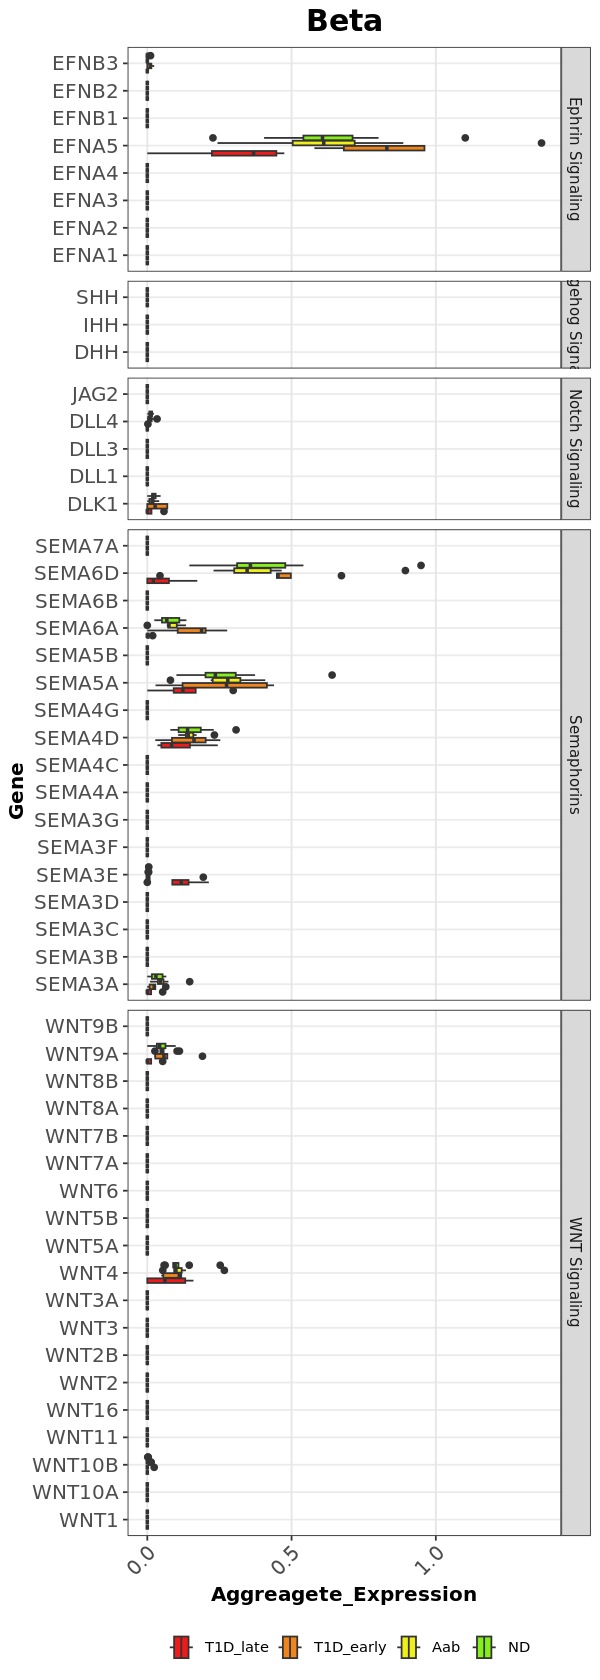

In [820]:
options(repr.plot.width=5, repr.plot.height=14)
ggplot(means.mat.use, aes(x = mean, y = gene, fill = condition)) +
      geom_boxplot() +
      labs(x = "Aggreagete_Expression", y = "Gene", title = means.mat.use$cellpop[1]) +
      scale_fill_manual(values = colors.conditions) +
      theme_bw() +
      theme(axis.text = element_text(size = 12),
            axis.text.x = element_text(angle = 45, hjust = 1),
            axis.title = element_text(size = 12, face = "bold"),
            legend.title = element_blank(),
            legend.position = "bottom",
            strip.text.y = element_text(size = 9),
            plot.title = element_text(size = 18, face = "bold", hjust = 0.5),
            panel.grid.major.x = element_line(colour = "gray90"),
            panel.grid.minor.x = element_blank())+ 
    facet_nested(rows = vars(Functional.sub.classification),
                 scales = "free", space = "free_y")

In [709]:
filter(means.mat.use, gene == "CD1D")

gene,sample,condition,cellpop,mean,Type,Mode.of.Action,Functional.classification,Functional.sub.classification,Gene.Family,compartment
<chr>,<int>,<fct>,<chr>,<dbl>,<chr>,<chr>,<fct>,<chr>,<chr>,<fct>
CD1D,6197,Aab,Beta,0,Ligand,Cell-Cell Contact,Antigen-Presenting Molecules,MHC - like molecule,CD Family,Endocrine
CD1D,6220,T1D_late,Beta,0,Ligand,Cell-Cell Contact,Antigen-Presenting Molecules,MHC - like molecule,CD Family,Endocrine
CD1D,6228,T1D_early,Beta,0,Ligand,Cell-Cell Contact,Antigen-Presenting Molecules,MHC - like molecule,CD Family,Endocrine
CD1D,6229,ND,Beta,0,Ligand,Cell-Cell Contact,Antigen-Presenting Molecules,MHC - like molecule,CD Family,Endocrine
CD1D,6234,ND,Beta,0,Ligand,Cell-Cell Contact,Antigen-Presenting Molecules,MHC - like molecule,CD Family,Endocrine
CD1D,6236,T1D_late,Beta,0,Ligand,Cell-Cell Contact,Antigen-Presenting Molecules,MHC - like molecule,CD Family,Endocrine
CD1D,6264,T1D_late,Beta,0,Ligand,Cell-Cell Contact,Antigen-Presenting Molecules,MHC - like molecule,CD Family,Endocrine
CD1D,6267,Aab,Beta,0,Ligand,Cell-Cell Contact,Antigen-Presenting Molecules,MHC - like molecule,CD Family,Endocrine
CD1D,6282,ND,Beta,0,Ligand,Cell-Cell Contact,Antigen-Presenting Molecules,MHC - like molecule,CD Family,Endocrine


In [ ]:
# Do statistic test for genes too
# Add stars to each plot